# Week 7 - Classification Models: Logistic Regression & k-Nearest Neighbors
### CSE 432 / 532 - Machine Learning - Instructor Demo

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import Image, display
from urllib.request import urlopen
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('All libraries loaded.')
print('scikit-learn version:', sklearn.__version__)

All libraries loaded.
scikit-learn version: 1.8.0


---
## Recap: Linear Regression (Week 6)

Last week we used **linear regression** to predict a *continuous* outcome (e.g., exam score from study hours).

Quick refresher:
- **Model:** $\hat{y} = w_0 + w_1 x$, a straight line through the data.
- **Objective:** minimize the sum of squared errors $\sum (y_i - \hat{y}_i)^2$.
- **Output:** any real number (unbounded).

This week we shift to **classification**, i.e., predicting a *category* (e.g., which species of penguin?).

Can we just reuse linear regression for this? Let's find out. Revisit the linear model below, then press **"Switch to Classification"** to see what happens when $y$ becomes binary (0 or 1).

### Interactive Demo: Linear Regression to Classification

Click anywhere on the canvas below to place data points. A regression line updates instantly via the **Normal Equation**.

Once you have several points, press **"Switch to Classification"** to convert $y$ to binary (0 or 1) and see why linear regression struggles.

In [3]:
# @title
from IPython.display import HTML
HTML("""
<div id="w7_wrap" style="font-family:'Segoe UI',sans-serif;background:#f0fdf4;padding:20px;border-radius:10px;max-width:660px;border:1px solid #bbf7d0;">
  <h3 style="margin:0 0 6px 0;color:#14532d;font-size:16px;">&#128433; Regression → Classification: Click to Add Points</h3>
  <p id="w7_desc" style="margin:0 0 12px 0;color:#475569;font-size:12px;">
    <b>Step 1:</b> Click to place continuous data points. The regression line updates via the Normal Equation.<br>
    <b>Step 2:</b> Press <em>"Switch to Classification"</em> to convert y to binary (0/1) and see what happens to the line.
  </p>
  <svg id="w7_svg" width="620" height="300" style="display:block;background:#fff;border-radius:6px;border:1px solid #d1fae5;cursor:crosshair;"></svg>
  <div style="margin-top:12px;display:flex;gap:14px;align-items:center;flex-wrap:wrap;">
    <div style="font-size:12px;background:#fff;border:1px solid #a7f3d0;border-radius:5px;padding:6px 12px;">
      <b>n</b> = <span id="w7_n" style="color:#065f46;">0</span>
    </div>
    <div style="font-size:12px;background:#fff;border:1px solid #a7f3d0;border-radius:5px;padding:6px 12px;">
      w&#8320; = <span id="w7_b0" style="color:#065f46;">—</span>
    </div>
    <div style="font-size:12px;background:#fff;border:1px solid #a7f3d0;border-radius:5px;padding:6px 12px;">
      w&#8321; = <span id="w7_b1" style="color:#065f46;">—</span>
    </div>
    <div style="font-size:12px;background:#fff;border:1px solid #a7f3d0;border-radius:5px;padding:6px 12px;">
      &#375; = <span id="w7_eq" style="color:#065f46;font-style:italic;">—</span>
    </div>
  </div>
  <div style="margin-top:10px;display:flex;gap:10px;align-items:center;flex-wrap:wrap;">
    <button id="w7_classify_btn" style="padding:7px 14px;background:#7c3aed;color:#fff;border:none;border-radius:6px;cursor:pointer;font-size:12px;font-weight:600;">&#9889; Switch to Classification</button>
    <button id="w7_clear" style="padding:7px 14px;background:#059669;color:#fff;border:none;border-radius:6px;cursor:pointer;font-size:12px;font-weight:600;">&#10005; Clear All</button>
    <span id="w7_msg" style="font-size:11px;color:#7c3aed;font-weight:600;display:none;"></span>
  </div>
</div>
<script>
(function(){
  var W=620,H=300,pl=55,pr=20,pt=20,pb=40;
  var ns="http://www.w3.org/2000/svg";
  var svg=document.getElementById('w7_svg');
  var pts=[];
  var classMode=false;
  var xmin=0,xmax=10,ymin=0,ymax=10;

  function xs(x){return pl+(x-xmin)/(xmax-xmin)*(W-pl-pr);}
  function ys(y){return pt+(1-(y-ymin)/(ymax-ymin))*(H-pt-pb);}
  function ixs(px){return xmin+(px-pl)/(W-pl-pr)*(xmax-xmin);}
  function iys(py){return ymin+(1-(py-pt)/(H-pt-pb))*(ymax-ymin);}
  function el(tag,attrs,txt){var e=document.createElementNS(ns,tag);for(var k in attrs)e.setAttribute(k,attrs[k]);if(txt!==undefined)e.textContent=txt;return e;}

  var axesG=el('g',{});svg.appendChild(axesG);
  function drawAxes(){
    while(axesG.firstChild)axesG.removeChild(axesG.firstChild);
    axesG.appendChild(el('line',{x1:pl,y1:H-pb,x2:W-pr,y2:H-pb,stroke:'#334155','stroke-width':'1.5'}));
    axesG.appendChild(el('line',{x1:pl,y1:pt,x2:pl,y2:H-pb,stroke:'#334155','stroke-width':'1.5'}));
    for(var xi=0;xi<=10;xi+=2){
      var px=xs(xi);
      axesG.appendChild(el('line',{x1:px,y1:H-pb,x2:px,y2:pt,stroke:'#f1f5f9','stroke-width':'0.8'}));
      axesG.appendChild(el('line',{x1:px,y1:H-pb,x2:px,y2:H-pb+4,stroke:'#64748b','stroke-width':'1'}));
      axesG.appendChild(el('text',{x:px,y:H-pb+15,'text-anchor':'middle','font-size':'10',fill:'#64748b'},xi));
    }
    if(!classMode){
      for(var yi=0;yi<=10;yi+=2){
        var py=ys(yi);
        axesG.appendChild(el('line',{x1:pl,y1:py,x2:W-pr,y2:py,stroke:'#f1f5f9','stroke-width':'0.8'}));
        axesG.appendChild(el('line',{x1:pl-4,y1:py,x2:pl,y2:py,stroke:'#64748b','stroke-width':'1'}));
        axesG.appendChild(el('text',{x:pl-7,y:py+4,'text-anchor':'end','font-size':'10',fill:'#64748b'},yi));
      }
    } else {
      [0,1].forEach(function(v){
        var py=ys(v);
        axesG.appendChild(el('line',{x1:pl,y1:py,x2:W-pr,y2:py,stroke:'#e2e8f0','stroke-width':'0.8'}));
        axesG.appendChild(el('text',{x:pl-7,y:py+4,'text-anchor':'end','font-size':'11',fill:'#374151','font-weight':'bold'},v));
      });
      var py5=ys(0.5);
      axesG.appendChild(el('line',{x1:pl,y1:py5,x2:W-pr,y2:py5,stroke:'#9333ea','stroke-width':'1.2','stroke-dasharray':'5,4',opacity:'0.6'}));
      axesG.appendChild(el('text',{x:W-pr+2,y:py5+4,'text-anchor':'start','font-size':'9',fill:'#9333ea','font-weight':'600'},'T=0.5'));
    }
    axesG.appendChild(el('text',{x:W/2,y:H-5,'text-anchor':'middle','font-size':'11',fill:'#374151'},'x'));
    var ylbl=classMode?'y (class: 0 or 1)':'y';
    var yt=el('text',{x:13,y:H/2,'text-anchor':'middle','font-size':'11',fill:'#374151',transform:'rotate(-90,13,'+(H/2)+')'},ylbl);
    axesG.appendChild(yt);
  }

  var rline=el('line',{stroke:'#16a34a','stroke-width':'2.5',opacity:'0'});svg.appendChild(rline);
  var probG=el('g',{});svg.appendChild(probG);
  var pg=el('g',{});svg.appendChild(pg);
  var hintTxt=el('text',{x:W/2,y:H/2,'text-anchor':'middle','font-size':'13',fill:'#cbd5e1'},'Click to add points');
  svg.appendChild(hintTxt);

  function fitLine(){
    var n=pts.length;
    if(n<2){rline.setAttribute('opacity','0');
      document.getElementById('w7_b0').textContent='\u2014';
      document.getElementById('w7_b1').textContent='\u2014';
      document.getElementById('w7_eq').textContent='\u2014';return;}
    var xbar=pts.reduce(function(s,p){return s+p.x;},0)/n;
    var ybar=pts.reduce(function(s,p){return s+p.y;},0)/n;
    var ssxy=pts.reduce(function(s,p){return s+(p.x-xbar)*(p.y-ybar);},0);
    var ssxx=pts.reduce(function(s,p){return s+(p.x-xbar)*(p.x-xbar);},0);
    if(ssxx<1e-10){rline.setAttribute('opacity','0');return;}
    var b1=ssxy/ssxx, b0=ybar-b1*xbar;
    var y0=b0+b1*xmin, y1v=b0+b1*xmax;
    rline.setAttribute('x1',xs(xmin));rline.setAttribute('y1',ys(y0));
    rline.setAttribute('x2',xs(xmax));rline.setAttribute('y2',ys(y1v));
    rline.setAttribute('opacity','1');
    rline.setAttribute('stroke', classMode ? '#dc2626' : '#16a34a');
    document.getElementById('w7_b0').textContent=b0.toFixed(3);
    document.getElementById('w7_b1').textContent=b1.toFixed(3);
    document.getElementById('w7_eq').textContent=b0.toFixed(2)+(b1>=0?' + ':' \u2212 ')+Math.abs(b1).toFixed(2)+'\u00b7x';

    while(probG.firstChild)probG.removeChild(probG.firstChild);
    if(classMode && n>=2){
      var xAt0=(0-b0)/b1, xAt1=(1-b0)/b1;
      if(b1>0 && xAt0>xmin){
        var x0c=Math.min(xAt0,xmax);
        probG.appendChild(el('rect',{x:xs(xmin),y:pt,width:xs(x0c)-xs(xmin),height:H-pt-pb,fill:'#fecaca',opacity:'0.25'}));
        probG.appendChild(el('text',{x:xs((xmin+x0c)/2),y:pt+16,'text-anchor':'middle','font-size':'9',fill:'#dc2626','font-weight':'600'},'\u0177 < 0 \u2717'));
      }
      if(b1>0 && xAt1<xmax){
        var x1c=Math.max(xAt1,xmin);
        probG.appendChild(el('rect',{x:xs(x1c),y:pt,width:xs(xmax)-xs(x1c),height:H-pt-pb,fill:'#fecaca',opacity:'0.25'}));
        probG.appendChild(el('text',{x:xs((x1c+xmax)/2),y:pt+16,'text-anchor':'middle','font-size':'9',fill:'#dc2626','font-weight':'600'},'\u0177 > 1 \u2717'));
      }
      if(b1<0 && xAt0<xmax){
        var x0c2=Math.max(xAt0,xmin);
        probG.appendChild(el('rect',{x:xs(x0c2),y:pt,width:xs(xmax)-xs(x0c2),height:H-pt-pb,fill:'#fecaca',opacity:'0.25'}));
        probG.appendChild(el('text',{x:xs((x0c2+xmax)/2),y:pt+16,'text-anchor':'middle','font-size':'9',fill:'#dc2626','font-weight':'600'},'\u0177 < 0 \u2717'));
      }
      if(b1<0 && xAt1>xmin){
        var x1c2=Math.min(xAt1,xmax);
        probG.appendChild(el('rect',{x:xs(xmin),y:pt,width:xs(x1c2)-xs(xmin),height:H-pt-pb,fill:'#fecaca',opacity:'0.25'}));
        probG.appendChild(el('text',{x:xs((xmin+x1c2)/2),y:pt+16,'text-anchor':'middle','font-size':'9',fill:'#dc2626','font-weight':'600'},'\u0177 > 1 \u2717'));
      }
    }
  }

  function drawPoints(){
    while(pg.firstChild)pg.removeChild(pg.firstChild);
    pts.forEach(function(p){
      var color=classMode?(p.y>0.5?'#3b82f6':'#f97316'):'#0f766e';
      pg.appendChild(el('circle',{cx:xs(p.x),cy:ys(p.y),r:'5.5',fill:color,stroke:'white','stroke-width':'1.5'}));
    });
    document.getElementById('w7_n').textContent=pts.length;
  }

  svg.addEventListener('click',function(e){
    var rect=svg.getBoundingClientRect();
    var px=e.clientX-rect.left, py=e.clientY-rect.top;
    var dx=ixs(px), dy=iys(py);
    if(dx<xmin||dx>xmax||dy<ymin||dy>ymax)return;
    if(classMode){dy=dy>=0.5?1:0;}
    hintTxt.setAttribute('opacity','0');
    pts.push({x:dx,y:dy,origY:dy});
    drawPoints(); fitLine();
  });

  document.getElementById('w7_classify_btn').addEventListener('click',function(){
    if(pts.length<3){
      document.getElementById('w7_msg').textContent='\u26a0 Add at least 3 points first!';
      document.getElementById('w7_msg').style.display='';return;
    }
    classMode=!classMode;
    this.textContent=classMode?'\u21a9 Back to Regression':'\u26a1 Switch to Classification';
    this.style.background=classMode?'#dc2626':'#7c3aed';
    document.getElementById('w7_msg').style.display='none';

    if(classMode){
      var med=pts.slice().sort(function(a,b){return a.origY-b.origY;})[Math.floor(pts.length/2)].origY;
      pts.forEach(function(p){p.y=p.origY>=med?1:0;});
      ymin=-0.3; ymax=1.5;
      document.getElementById('w7_msg').textContent='\u26a0 Linear regression predicts outside [0,1] \u2014 we need logistic regression!';
      document.getElementById('w7_msg').style.display='';
      document.getElementById('w7_msg').style.color='#dc2626';
    } else {
      pts.forEach(function(p){p.y=p.origY;});
      ymin=0; ymax=10;
      document.getElementById('w7_msg').style.display='none';
    }
    drawAxes(); drawPoints(); fitLine();
  });

  document.getElementById('w7_clear').addEventListener('click',function(){
    pts=[];classMode=false;ymin=0;ymax=10;
    while(pg.firstChild)pg.removeChild(pg.firstChild);
    while(probG.firstChild)probG.removeChild(probG.firstChild);
    rline.setAttribute('opacity','0');
    hintTxt.setAttribute('opacity','1');
    document.getElementById('w7_n').textContent='0';
    document.getElementById('w7_b0').textContent='\u2014';
    document.getElementById('w7_b1').textContent='\u2014';
    document.getElementById('w7_eq').textContent='\u2014';
    document.getElementById('w7_msg').style.display='none';
    document.getElementById('w7_classify_btn').textContent='\u26a1 Switch to Classification';
    document.getElementById('w7_classify_btn').style.background='#7c3aed';
    drawAxes();
  });

  drawAxes();
})();
</script>
""")


### "But can't we just threshold at 0.5?"

Thresholding a linear regression *can* work on simple toy examples.
But there are **several problems** beyond just the out-of-range values:

**1. Sensitive to outliers** (most visible problem)

Linear regression minimizes **squared error** across all points. A single extreme observation
can tilt the entire line, shifting where it crosses 0.5 and **flipping previously correct predictions**.
Logistic regression's sigmoid saturates at 0 and 1, so extreme points barely affect the boundary.
*(See the plot below.)*

**2. Wrong objective function**

Linear regression minimizes $\sum(y_i - \hat{y}_i)^2$, it's trying to **get close to 0 and 1 in LS sense (aproperiate for continious metrics)**,
not trying to **separate the classes**. A point that is *very* correctly classified (e.g., $\hat{y} = 0.99$ when $y = 1$)
still pulls the line toward it, even though no improvement is needed. Logistic regression maximizes
the **likelihood** of the observed labels i.e. it focuses on getting the boundary right and not the residual (error).

**3. Outputs aren't calibrated probabilities**

Even where $\hat{y}$ falls between 0 and 1, it's not a meaningful probability.
Linear regression can say $\hat{y} = 0.7$ for one point and $\hat{y} = 0.8$ for another,
but those values don't reflect the true confidence of the prediction.
Logistic regression produces **proper probabilities** by construction (via the sigmoid).

**4. Violates linear regression assumptions**

With binary $y \in \{0, 1\}$, the residuals cannot be normally distributed (they're bimodal),
and the variance is not constant (heteroscedasticity is guaranteed). The standard errors,
confidence intervals, and hypothesis tests from a linear regression would all be **invalid**.

> **Bottom line:** Thresholding *sometimes works*, but logistic regression is better because it
> optimizes for classification directly, produces calibrated probabilities, and is robust to extremes.

Run the cell below to see problem #1 (outlier sensitivity) in action.

In [2]:
# --- Outlier sensitivity: Linear Regression vs Logistic Regression ---
from sklearn.linear_model import LinearRegression

np.random.seed(42)

# Base dataset: two clean clusters
x_class0 = np.random.normal(2, 0.8, 12)    # class 0 centered at x=3
x_class1 = np.random.normal(5, 0.8, 12)    # class 1 centered at x=7
X_base = np.concatenate([x_class0, x_class1]).reshape(-1, 1)
y_base = np.array([0]*12 + [1]*12)

# Add one extreme outlier: class 1 at x=20
X_outlier = np.vstack([X_base, [[20]]])
y_outlier = np.append(y_base, 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for col, (X, y, label) in enumerate([
    (X_base, y_base, 'Without outlier'),
    (X_outlier, y_outlier, 'With outlier at x=20'),
]):
    x_plot = np.linspace(X.min() - 1, X.max() + 1, 300).reshape(-1, 1)

    # --- Top row: Linear Regression + threshold ---
    ax = axes[0, col]
    lr = LinearRegression().fit(X, y)
    y_line = lr.predict(x_plot)
    ax.scatter(X[y==0], y[y==0], c='#f97316', s=50, edgecolors='white', zorder=5, label='Class 0')
    ax.scatter(X[y==1], y[y==1], c='#3b82f6', s=50, edgecolors='white', zorder=5, label='Class 1')
    ax.plot(x_plot, y_line, 'r-', linewidth=2.5, label='Linear regression')
    ax.axhline(0.5, color='gray', ls='--', alpha=0.6, label='Threshold T=0.5')

    # Find where line crosses 0.5
    x_cross = (0.5 - lr.intercept_) / lr.coef_[0]
    ax.axvline(x_cross, color='#9333ea', ls=':', linewidth=2, alpha=0.8,
               label=f'Decision boundary (x={x_cross:.1f})')

    # Shade misclassified region (class 1 points left of boundary)
    misclass = ((X.ravel() < x_cross) & (y == 1)) | ((X.ravel() >= x_cross) & (y == 0))
    if misclass.any():
        ax.scatter(X[misclass], y[misclass], facecolors='none', edgecolors='red',
                   s=120, linewidths=2, zorder=6, label='Misclassified')

    ax.set_ylim(-0.15, 1.15)
    ax.set_ylabel(r'$\hat{y}$ (linear regression)')
    ax.set_title(f'Linear Regression - {label}', fontweight='bold')
    ax.legend(fontsize=8, loc='center right')

    # --- Bottom row: Logistic Regression ---
    ax2 = axes[1, col]
    logr = LogisticRegression(penalty=None, max_iter=1000).fit(X, y)
    y_prob = logr.predict_proba(x_plot)[:, 1]
    ax2.scatter(X[y==0], y[y==0], c='#f97316', s=50, edgecolors='white', zorder=5, label='Class 0')
    ax2.scatter(X[y==1], y[y==1], c='#3b82f6', s=50, edgecolors='white', zorder=5, label='Class 1')
    ax2.plot(x_plot, y_prob, 'g-', linewidth=2.5, label='Logistic regression')
    ax2.axhline(0.5, color='gray', ls='--', alpha=0.6, label='Threshold T=0.5')

    x_cross_log = -logr.intercept_[0] / logr.coef_[0][0]
    ax2.axvline(x_cross_log, color='#9333ea', ls=':', linewidth=2, alpha=0.8,
                label=f'Decision boundary (x={x_cross_log:.1f})')

    ax2.set_ylim(-0.15, 1.15)
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$P(\mathrm{class\;1})$')
    ax2.set_title(f'Logistic Regression - {label}', fontweight='bold')
    ax2.legend(fontsize=8, loc='center right')

plt.suptitle('Why Linear Regression Fails for Classification: Outlier Sensitivity',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print the boundary shift
lr_base = LinearRegression().fit(X_base, y_base)
lr_out  = LinearRegression().fit(X_outlier, y_outlier)
logr_base = LogisticRegression(penalty=None, max_iter=1000).fit(X_base, y_base)
logr_out  = LogisticRegression(penalty=None, max_iter=1000).fit(X_outlier, y_outlier)

xb_lin = (0.5 - lr_base.intercept_) / lr_base.coef_[0]
xo_lin = (0.5 - lr_out.intercept_) / lr_out.coef_[0]
xb_log = -logr_base.intercept_[0] / logr_base.coef_[0][0]
xo_log = -logr_out.intercept_[0] / logr_out.coef_[0][0]

print(f'Decision boundary shift after adding outlier:')
print(f'  Linear Regression:   {xb_lin:.1f} -> {xo_lin:.1f}  (shifted by {xo_lin - xb_lin:+.1f})')
print(f'  Logistic Regression: {xb_log:.1f} -> {xo_log:.1f}  (shifted by {xo_log - xb_log:+.1f})')
print(f'\n>> The linear regression boundary moved much more - misclassifying points near the middle!')

NameError: name 'np' is not defined

---
## The Fix: From Linear Regression to Logistic Regression

We've seen that linear regression breaks down for classification because:
1. Outputs can go below 0 or above 1; these are not valid probabilities.
2. The squared-error objective doesn't focus on separating classes.
3. Outliers can shift the entire line and flip predictions.

The natural fix? **Keep the linear core, but wrap it in a function that forces the output into $[0, 1]$.**

That function is the **sigmoid** (logistic function), and the resulting model is **logistic regression**, the "classification cousin" of linear regression.

$$\text{Linear regression: }   \hat{y} = w_0 + w_1 x \quad\quad \text{(unbounded)}$$
$$\text{Logistic regression: }  \hat{p} = \frac{\exp(w_0 + w_1 x)}{1 + \exp(w_0 + w_1 x)} \quad\quad\text{(bounded to } [0,1] \text{)}$$

Let's see how this works using some real data.

### Our running example: *Palmer Penguins*

The **Palmer Penguins** dataset has body measurements for three species:
**Adelie**, **Chinstrap**, and **Gentoo**.

![Palmer](images/Palmer.png)

| Feature | Description |
|---|---|
| `bill_length_mm` | Length of the penguin's bill (mm) |
| `bill_depth_mm` | Depth of the penguin's bill (mm) |
| `flipper_length_mm` | Length of the flipper (mm) |
| `body_mass_g` | Body mass (g) |
| `species` | Adelie, Chinstrap, or Gentoo |


In [103]:
# Load the Palmer Penguins dataset
penguins = sns.load_dataset('penguins').dropna()
print(f'Shape: {penguins.shape}')
penguins.head()

Shape: (333, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [104]:
# Quick look at descriptive statistics
penguins.describe().round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.00,333.00,333.00,333.00
mean,43.99,17.16,200.97,4207.06
std,5.47,1.97,14.02,805.22
min,32.10,13.10,172.00,2700.00
25%,39.50,15.60,190.00,3550.00
50%,44.50,17.30,197.00,4050.00
75%,48.60,18.70,213.00,4775.00
max,59.60,21.50,231.00,6300.00


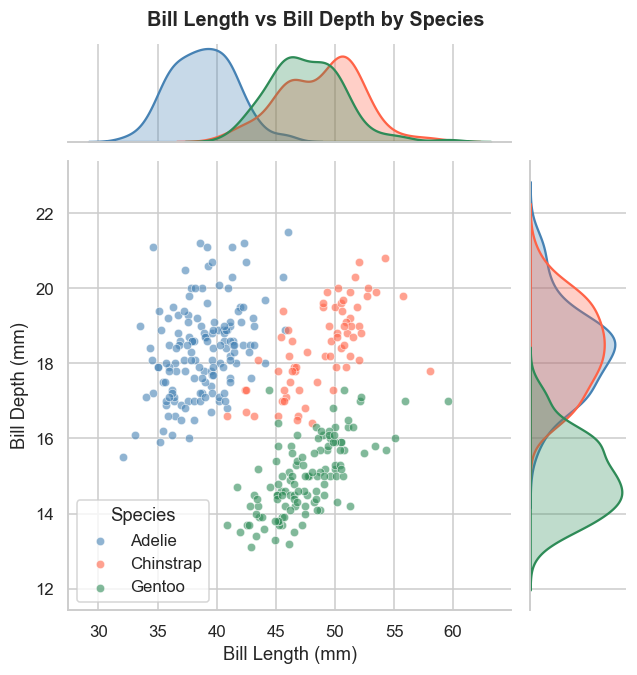

In [105]:
# Visualize species clusters by bill dimensions - scatter with marginal distributions
species_colors = {'Adelie': 'steelblue', 'Chinstrap': 'tomato', 'Gentoo': 'seagreen'}

g = sns.JointGrid(data=penguins, x='bill_length_mm', y='bill_depth_mm', height=6, ratio=4)

for sp, color in species_colors.items():
    subset = penguins[penguins['species'] == sp]
    g.ax_joint.scatter(subset['bill_length_mm'], subset['bill_depth_mm'],
                       c=color, label=sp, alpha=0.6, s=30, edgecolors='white', linewidth=0.5)
    sns.kdeplot(subset['bill_length_mm'], ax=g.ax_marg_x, color=color, fill=True, alpha=0.3, linewidth=1.5)
    sns.kdeplot(subset['bill_depth_mm'], ax=g.ax_marg_y, vertical=True, color=color, fill=True, alpha=0.3, linewidth=1.5)

g.ax_joint.set_xlabel('Bill Length (mm)')
g.ax_joint.set_ylabel('Bill Depth (mm)')
g.ax_joint.legend(title='Species')
g.figure.suptitle('Bill Length vs Bill Depth by Species', y=1.02, fontsize=13, fontweight='bold')
plt.show()

---
## Part 1 - Logistic Regression (Sec. 7.1)

### The Logistic (Sigmoid) Function

One strategy for improving model-based algorithms is to apply a **transformation**.

Let $p_i$ = probability that $y_i = 1$ for a given $x_i$.

The **log-odds** is:
$$g_i = \ln\!\left(\frac{p_i}{1 - p_i}\right)$$

The log-odds $g_i$ ranges from $-\infty$ to $+\infty$, unlike $p_i$ which is bounded between 0 and 1.

**Logistic regression** models the log-odds as a linear function:
$$\ln\!\left(\frac{p_i}{1 - p_i}\right) = w_0 + w_1 x_i$$

Rearranging gives the **sigmoid function**:
$$\hat{p}_i = \frac{\exp(w_0 + w_1 x_i)}{1 + \exp(w_0 + w_1 x_i)}$$

where $\exp(x) = e^x$. The predicted values $\hat{p}_i$ represent the **probability** that $y_i = 1$.

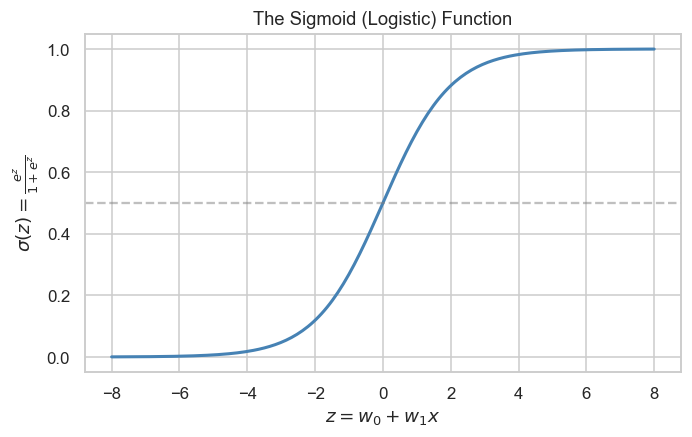

Key property: output is always between 0 and 1 -> interpretable as a probability.


In [106]:
# Demonstrate the sigmoid function
def sigmoid(z):
    return np.exp(z) / (1 + np.exp(z))

z_vals = np.linspace(-8, 8, 200)

plt.figure(figsize=(7, 4))
plt.plot(z_vals, sigmoid(z_vals), color='steelblue', linewidth=2)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.xlabel(r'$z = w_0 + w_1 x$')
plt.ylabel(r'$\sigma(z) = \frac{e^z}{1 + e^z}$')
plt.title('The Sigmoid (Logistic) Function')
plt.ylim(-0.05, 1.05)
plt.show()

print('Key property: output is always between 0 and 1 -> interpretable as a probability.')

### Example: Is this penguin Adelie?

Let's use bill length ($x$) to predict whether a penguin is Adelie ($y=1$) or not ($y=0$).

The ZyBook provides a logistic regression model:
$$\hat{p} = \frac{\exp(50.24 - 1.172 x)}{1 + \exp(50.24 - 1.172 x)}$$

**Example calculation**: penguin with bill length $x = 42$ mm:
$$\hat{p} = \frac{\exp(50.24 - 1.172 \times 42)}{1 + \exp(50.24 - 1.172 \times 42)} = 0.734$$

- Probability Adelie ($y = 1$): $\hat{p} = 0.734$
- Probability not Adelie ($y = 0$): $1 - \hat{p} = 0.266$

In [107]:
# Prepare binary target: Adelie vs not-Adelie
penguins['is_adelie'] = (penguins['species'] == 'Adelie').astype(int)

X_bill = penguins[['bill_length_mm']]
y_adelie = penguins['is_adelie']

# Fit logistic regression (single feature: bill length)
log_model_simple = LogisticRegression(penalty=None, max_iter=1000)
log_model_simple.fit(X_bill, y_adelie)

w0 = log_model_simple.intercept_[0]
w1 = log_model_simple.coef_[0][0]
print(f'Intercept (w0): {w0:.2f}')
print(f'Slope     (w1): {w1:.2f}')
print(f'\nModel: p̂ = exp({w0:.2f} + ({w1:.2f})·x) / (1 + exp({w0:.2f} + ({w1:.2f})·x))')

Intercept (w0): 50.24
Slope     (w1): -1.17

Model: p̂ = exp(50.24 + (-1.17)·x) / (1 + exp(50.24 + (-1.17)·x))


In [108]:
# Calculate predicted probability for a penguin with bill length = 42 mm
x_example = 42
z = w0 + w1 * x_example
p_hat = np.exp(z) / (1 + np.exp(z))

print(f'Bill length x = {x_example} mm')
print(f'z = {w0:.2f} + ({w1:.2f}) × {x_example} = {z:.3f}')
print(f'$p_hat = {p_hat:.3f}$')
print(f'\nP(Adelie)     = {p_hat:.3f}')
print(f'P(not Adelie) = {1 - p_hat:.3f}')

Bill length x = 42 mm
z = 50.24 + (-1.17) × 42 = 1.032
$p_hat = 0.737$

P(Adelie)     = 0.737
P(not Adelie) = 0.263


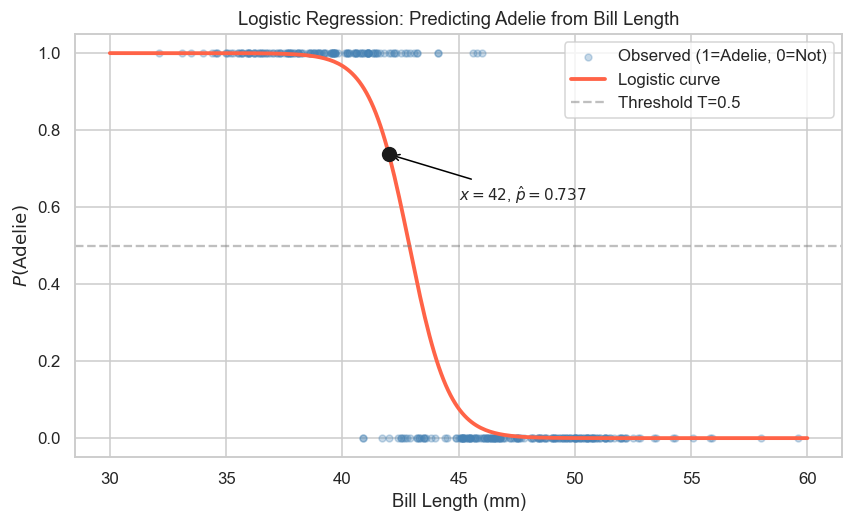

In [109]:
# Visualize the logistic regression curve
x_range = np.linspace(30, 60, 300).reshape(-1, 1)
p_range = log_model_simple.predict_proba(x_range)[:, 1]

plt.figure(figsize=(9, 5))
plt.scatter(penguins['bill_length_mm'], penguins['is_adelie'],
            alpha=0.3, s=20, color='steelblue', label='Observed (1=Adelie, 0=Not)')
plt.plot(x_range, p_range, color='tomato', linewidth=2.5, label='Logistic curve')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold T=0.5')

# Mark the example point
plt.plot(42, p_hat, 'ko', markersize=9, zorder=5)
plt.annotate(f'$x=42$, $\hat{{p}}={p_hat:.3f}$', xy=(42, p_hat), xytext=(45, p_hat - 0.12),
             fontsize=10, arrowprops=dict(arrowstyle='->', color='black'))

plt.xlabel('Bill Length (mm)')
plt.ylabel(r'$P(\mathrm{Adelie})$')
plt.title('Logistic Regression: Predicting Adelie from Bill Length')
plt.legend(loc='upper right')
plt.show()

### Classification Threshold
![Threshold](images/Threshold.png)

Logistic regression returns a **predicted probability** $\hat{p}_i$.
To convert to a class label, compare $\hat{p}_i$ to a **threshold** $T$:

$$\hat{y}_i = \begin{cases} 1 & \text{if } \hat{p}_i \ge T \\ 0 & \text{if } \hat{p}_i < T \end{cases}$$

- For binary classification, the most common threshold is $T = 0.5$.
- The threshold may be adjusted to avoid costly errors.
  - **Medical tests**: lower threshold to avoid missing a disease.
  - **Spam filter**: higher threshold to avoid blocking legitimate email.

> **Example (T = 0.5)**:
> - Bill length 42 mm: $\hat{p} = 0.734 \ge 0.5$ => **Adelie**
> - Bill length 45 mm: $\hat{p} = 0.076 < 0.5$ => **Not Adelie**

In [110]:
# Demonstrate classification with different thresholds
test_bills = [35, 38, 42, 45, 50, 55]
probs = log_model_simple.predict_proba(np.array(test_bills).reshape(-1, 1))[:, 1]

print(f'{"Bill Length":>12s}  {"P(Adelie)":>10s}  {"T=0.05":>8s}  {"T=0.5":>8s}  {"T=0.95":>8s}')
print('-' * 56)
for bl, p in zip(test_bills, probs):
    c50 = 'Adelie' if p >= 0.05 else 'Not'
    c30 = 'Adelie' if p >= 0.5 else 'Not'
    c70 = 'Adelie' if p >= 0.95 else 'Not'
    print(f'{bl:12d}  {p:10.3f}  {c50:>8s}  {c30:>8s}  {c70:>8s}')

print('\n> [Q] How does lowering the threshold change the predictions?')

 Bill Length   P(Adelie)    T=0.05     T=0.5    T=0.95
--------------------------------------------------------
          35       1.000    Adelie    Adelie    Adelie
          38       0.997    Adelie    Adelie    Adelie
          42       0.737    Adelie    Adelie       Not
          45       0.077    Adelie       Not       Not
          50       0.000       Not       Not       Not
          55       0.000       Not       Not       Not

> [Q] How does lowering the threshold change the predictions?


### Multiple Features in Logistic Regression

Logistic regression extends to **multiple input features** by adding terms:

$$\hat{p}_i = \frac{\exp(w_0 + w_1 x_{1i} + \cdots + w_p x_{pi})}{1 + \exp(w_0 + w_1 x_{1i} + \cdots + w_p x_{pi})}$$

In vector notation:
$$\hat{p}_i = \frac{\exp(w_0 + \mathbf{w}^T \mathbf{x}_i)}{1 + \exp(w_0 + \mathbf{w}^T \mathbf{x}_i)}$$

Adding input features complicates the model but typically results in **more accurate** classifications.

In [111]:
# Logistic regression with two features: bill_length_mm and bill_depth_mm
X_two = penguins[['bill_length_mm', 'bill_depth_mm']]
y_adelie = penguins['is_adelie']

log_model_two = LogisticRegression(penalty=None, max_iter=1000)
log_model_two.fit(X_two, y_adelie)

w0_2 = log_model_two.intercept_[0]
w1_2, w2_2 = log_model_two.coef_[0]

print(f'w0 (intercept)   = {w0_2:.2f}')
print(f'w1 (bill_length) = {w1_2:.2f}')
print(f'w2 (bill_depth)  = {w2_2:.2f}')

w0 (intercept)   = 24.13
w1 (bill_length) = -2.21
w2 (bill_depth)  = 4.00


In [112]:
# Example: penguin with bill_length=50, bill_depth=22
x1_ex, x2_ex = 50, 22
z_ex = w0_2 + w1_2 * x1_ex + w2_2 * x2_ex
p_ex = np.exp(z_ex) / (1 + np.exp(z_ex))

print(f'Penguin: bill_length={x1_ex} mm, bill_depth={x2_ex} mm')
print(f'z = {w0_2:.2f} + ({w1_2:.2f})×{x1_ex} + ({w2_2:.2f})×{x2_ex} = {z_ex:.3f}')
print(f'p̂ = {p_ex:.3f}')
print(f'Classification (T=0.5): {"Adelie" if p_ex >= 0.5 else "Not Adelie"}')

Penguin: bill_length=50 mm, bill_depth=22 mm
z = 24.13 + (-2.21)×50 + (4.00)×22 = 1.595
p̂ = 0.831
Classification (T=0.5): Adelie


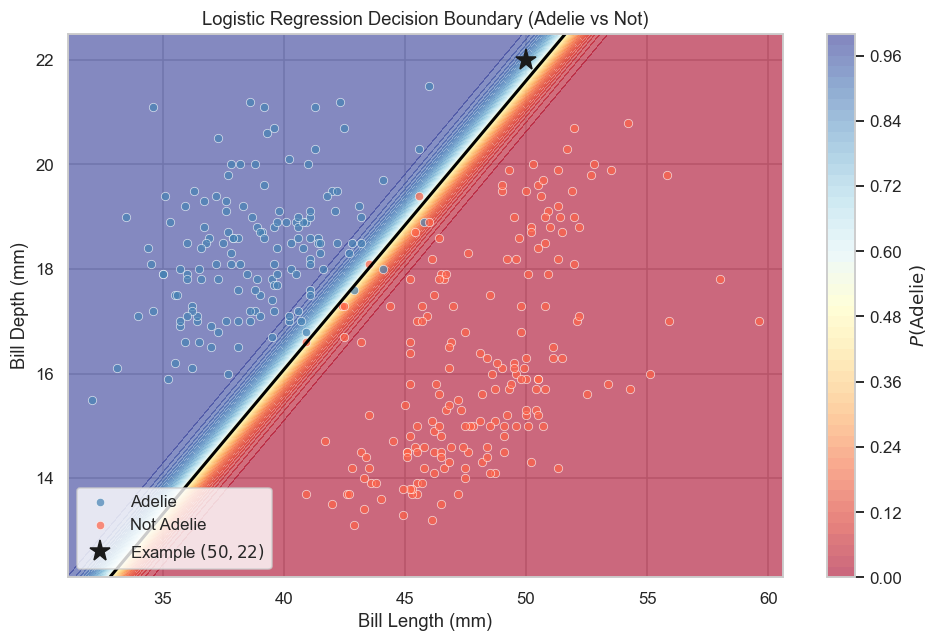

Darker blue = higher P(Adelie). Black line = decision boundary (p=0.5).


In [113]:
# Decision boundary plot for logistic regression with two features
fig, ax = plt.subplots(figsize=(9, 6))

# Create a mesh grid
x1_min, x1_max = X_two['bill_length_mm'].min() - 1, X_two['bill_length_mm'].max() + 1
x2_min, x2_max = X_two['bill_depth_mm'].min() - 1, X_two['bill_depth_mm'].max() + 1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                        np.linspace(x2_min, x2_max, 300))
grid = np.c_[xx1.ravel(), xx2.ravel()]

# Predict probabilities on the grid
probs_grid = log_model_two.predict_proba(grid)[:, 1].reshape(xx1.shape)

# Heatmap of probabilities
contour = ax.contourf(xx1, xx2, probs_grid, levels=50, cmap='RdYlBu', alpha=0.6)
plt.colorbar(contour, ax=ax, label=r'$P(\mathrm{Adelie})$')

# Decision boundary (p=0.5)
ax.contour(xx1, xx2, probs_grid, levels=[0.5], colors='black', linewidths=2)

# Scatter actual points
for sp, color in {'Adelie': 'steelblue', 'Not Adelie': 'tomato'}.items():
    if sp == 'Adelie':
        mask = penguins['is_adelie'] == 1
    else:
        mask = penguins['is_adelie'] == 0
    ax.scatter(penguins.loc[mask, 'bill_length_mm'], penguins.loc[mask, 'bill_depth_mm'],
              c=color, label=sp, edgecolors='white', linewidth=0.5, s=30, alpha=0.7)

# Mark example point
ax.plot(x1_ex, x2_ex, 'k*', markersize=14, zorder=5, label=f'Example $({x1_ex},{x2_ex})$')

ax.set_xlabel('Bill Length (mm)')
ax.set_ylabel('Bill Depth (mm)')
ax.set_title('Logistic Regression Decision Boundary (Adelie vs Not)')
ax.legend()
plt.tight_layout()
plt.show()

print('Darker blue = higher P(Adelie). Black line = decision boundary (p=0.5).')

### Interpreting Logistic Regression Weights

Since logistic regression is a **model-based** algorithm, the weights describe the relationship
between inputs and outputs:

- When $w_j > 0$: the predicted probability of class 1 **increases** as $x_j$ increases.
- When $w_j < 0$: the predicted probability of class 1 **decreases** as $x_j$ increases.

Logistic regression is a **binary** classification model: it only predicts between two classes.
When more than two classes exist, separate models must be used for each class (one-vs-rest).

In [114]:
# Interpret the weights from the two-feature model
print('Two-feature logistic regression (Adelie vs Not):')
print(f'  w1 (bill_length) = {w1_2:.2f}  ->  {"Longer bills -> LESS likely Adelie" if w1_2 < 0 else "Longer bills -> MORE likely Adelie"}')
print(f'  w2 (bill_depth)  = {w2_2:.2f}  ->  {"Deeper bills -> LESS likely Adelie" if w2_2 < 0 else "Deeper bills -> MORE likely Adelie"}')
print()

# Compare: fit for each species
for target_species in ['Adelie', 'Chinstrap', 'Gentoo']:
    y_bin = (penguins['species'] == target_species).astype(int)
    model = LogisticRegression(penalty=None, max_iter=1000)
    model.fit(X_two, y_bin)
    print(f'{target_species:>10s}:  w0={model.intercept_[0]:>7.2f},  '
          f'w1(bill_len)={model.coef_[0][0]:>7.2f},  '
          f'w2(bill_dep)={model.coef_[0][1]:>7.2f}')

Two-feature logistic regression (Adelie vs Not):
  w1 (bill_length) = -2.21  ->  Longer bills -> LESS likely Adelie
  w2 (bill_depth)  = 4.00  ->  Deeper bills -> MORE likely Adelie

    Adelie:  w0=  24.13,  w1(bill_len)=  -2.21,  w2(bill_dep)=   4.00
 Chinstrap:  w0= -31.43,  w1(bill_len)=   0.35,  w2(bill_dep)=   0.80
    Gentoo:  w0=  48.12,  w1(bill_len)=   0.56,  w2(bill_dep)=  -4.48


### Logistic Regression in scikit-learn

`LogisticRegression()` key parameters:

| Parameter | Default | Description |
|---|---|---|
| `penalty` | `"l2"` | Regularization: `"l2"`, `"l1"`, `"elasticnet"`, or `None` |
| `max_iter` | `100` | Max iterations to solve for weights |

Key attributes after fitting:
- `model.intercept_`: estimated intercept $w_0$
- `model.coef_`: estimated weights $w_1, \ldots, w_p$

Key methods:
- `model.predict(X)`: predicted class labels
- `model.predict_proba(X)`: predicted probabilities for each class

In [115]:
# Full example: logistic regression with all numeric features
feature_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X_full = penguins[feature_cols]
y_adelie = penguins['is_adelie']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_adelie, test_size=0.2, random_state=42, stratify=y_adelie)

# Fit logistic regression (with l2 regularization)
log_model_full = LogisticRegression(penalty='l2', max_iter=1000)
log_model_full.fit(X_train, y_train)

# Predictions
y_pred = log_model_full.predict(X_test)
y_prob = log_model_full.predict_proba(X_test)[:, 1]

print('Logistic Regression (4 features, L2 penalty)')
print(f'  Intercept: {log_model_full.intercept_[0]:.3f}')
print(f'  Weights:   {dict(zip(feature_cols, log_model_full.coef_[0].round(3)))}')
print(f'  Accuracy:  {metrics.accuracy_score(y_test, y_pred):.3f}')
print()
print('Classification Report:')
print(metrics.classification_report(y_test, y_pred, target_names=['Not Adelie', 'Adelie']))

Logistic Regression (4 features, L2 penalty)
  Intercept: 32.734
  Weights:   {'bill_length_mm': np.float64(-1.423), 'bill_depth_mm': np.float64(1.814), 'flipper_length_mm': np.float64(-0.063), 'body_mass_g': np.float64(0.002)}
  Accuracy:  0.985

Classification Report:
              precision    recall  f1-score   support

  Not Adelie       1.00      0.97      0.99        38
      Adelie       0.97      1.00      0.98        29

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



In [116]:
# Compare: penalty=None vs penalty='l2'
for pen in [None, 'l2']:
    m = LogisticRegression(penalty=pen, max_iter=1000)
    m.fit(X_train, y_train)
    acc = metrics.accuracy_score(y_test, m.predict(X_test))
    print(f'penalty={str(pen):>6s}  ->  accuracy={acc:.3f}  '
          f'weights={np.round(m.coef_[0], 3)}')

penalty=  None  ->  accuracy=1.000  weights=[-4.397e+00  7.547e+00  1.400e-02  6.000e-03]
penalty=    l2  ->  accuracy=0.985  weights=[-1.423  1.814 -0.063  0.002]


### Beyond Linear Boundaries: Polynomial Logistic Regression

Standard logistic regression produces a **linear** decision boundary because the log-odds are modeled as a linear function of the inputs:

$$\ln \frac{p}{1-p} = w_0 + w_1 x_1 + w_2 x_2$$

But what if the true boundary between classes is **curved**?

We can create **non-linear** decision boundaries by adding **polynomial (or interaction) features** before fitting logistic regression:

$$\ln \frac{p}{1-p} = w_0 + w_1 x_1 + w_2 x_2 + w_3 x_1^2 + w_4 x_2^2 + w_5 x_1 x_2$$

The model is still "linear in the parameters" $w_j$, but the decision boundary in the original $(x_1, x_2)$ space becomes a **curve** (ellipse, parabola, etc.).

> **Key insight:** Logistic regression is not limited to straight-line boundaries; it is limited to boundaries that are linear **in the feature space you give it**. Engineer richer features => get richer boundaries.

To see this, consider classifying **Chinstrap vs Not-Chinstrap** using bill length and bill depth. Chinstrap penguins cluster in a specific region of the feature space, surrounded by Adelie and Gentoo on different sides, so a straight line struggles to enclose them.

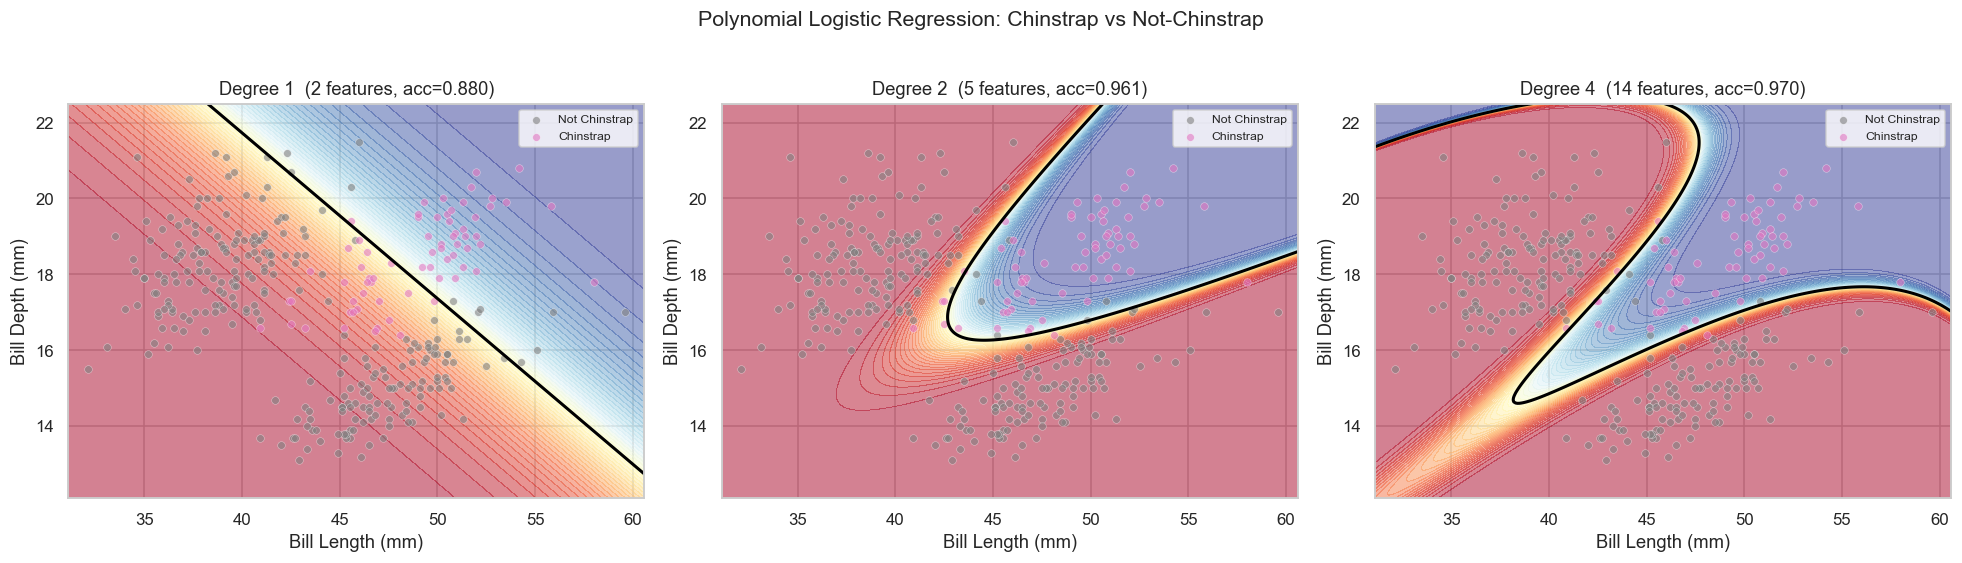

Degree 1: straight line - struggles to isolate Chinstrap cluster
Degree 2: curved boundary wraps around the Chinstrap region
Degree 4: even more flexible (risk of overfitting)

 Higher degree = more flexible, but more parameters -> risk of overfitting.


In [117]:
# Non-linear decision boundary via polynomial features
from sklearn.preprocessing import PolynomialFeatures

# Chinstrap vs Not-Chinstrap: Chinstrap clusters in a specific region
X_nl = penguins[['bill_length_mm', 'bill_depth_mm']].values
y_chin = (penguins['species'] == 'Chinstrap').astype(int).values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, degree in zip(axes, [1, 2, 4]):
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X_nl)

    # Fit logistic regression on expanded features
    lr_poly = LogisticRegression(penalty='l2', C=10.0, max_iter=5000)
    lr_poly.fit(X_poly, y_chin)

    # Build mesh grid in original feature space
    x1_min, x1_max = X_nl[:, 0].min() - 1, X_nl[:, 0].max() + 1
    x2_min, x2_max = X_nl[:, 1].min() - 1, X_nl[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                            np.linspace(x2_min, x2_max, 300))
    grid_raw = np.c_[xx1.ravel(), xx2.ravel()]
    grid_poly = poly.transform(grid_raw)

    # Predict probabilities -> decision boundary
    Z = lr_poly.predict_proba(grid_poly)[:, 1].reshape(xx1.shape)

    ax.contourf(xx1, xx2, Z, levels=50, cmap='RdYlBu', alpha=0.5)
    ax.contour(xx1, xx2, Z, levels=[0.5], colors='black', linewidths=2)

    for cls, color, lbl in [(0, 'gray', 'Not Chinstrap'), (1, '#e377c2', 'Chinstrap')]:
        mask = y_chin == cls
        ax.scatter(X_nl[mask, 0], X_nl[mask, 1], c=color,
                  label=lbl, s=25, alpha=0.6, edgecolors='white', linewidth=0.3)

    acc = lr_poly.score(X_poly, y_chin)
    n_features = X_poly.shape[1]
    ax.set_xlabel('Bill Length (mm)')
    ax.set_ylabel('Bill Depth (mm)')
    ax.set_title(f'Degree {degree}  ({n_features} features, acc={acc:.3f})')
    ax.legend(fontsize=8)

plt.suptitle('Polynomial Logistic Regression: Chinstrap vs Not-Chinstrap', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Degree 1: straight line - struggles to isolate Chinstrap cluster')
print('Degree 2: curved boundary wraps around the Chinstrap region')
print('Degree 4: even more flexible (risk of overfitting)')
print('\n Higher degree = more flexible, but more parameters -> risk of overfitting.')

---
## Two Approaches to Classification

Now that we've seen logistic regression in action, let's step back and place it in a broader framework. There are two fundamentally different classification strategies:

### Approach 1 - Model-Based (Parametric) [done] *what we just did*

Just like linear regression learns an equation $\hat{y} = w_0 + w_1 x$,
a **model-based classifier** learns a mathematical function from the data,
but one designed for classification.

- It estimates a fixed set of **parameters** ($w_0, w_1, \ldots$) during training.
- Once trained, predictions come from the equation alone; the training data can be discarded.
- **Example:** **Logistic Regression** (Sec. 7.1): wraps the linear function in a **sigmoid**
  to produce a probability $\hat{p} \in [0, 1]$.

### Approach 2 - Instance-Based (Non-Parametric) ... *coming up next*

What if we skip learning an equation altogether?

- An **instance-based classifier** stores the training data and, at prediction time,
  looks at the **most similar known examples** to decide.
- No equation, no parameters -- just "You are the majority of your $k$ closest friends!"
- **Example:** **k-Nearest Neighbors** (Sec. 7.2): classify by majority vote
  among the $k$ closest training instances.

> **Key contrast:** Logistic regression draws a **global** decision boundary (a line/hyperplane) using a mathematical equation.
> kNN creates a **local** boundary that adapts to the shape of the data, but needs the training set at prediction time.


| | **Parametric (Model-Based)** | **Non-Parametric (Instance-Based)** |
|---|---|---|
| **Assumption** | The data-generating process can be described by a model with a **fixed, finite number of parameters** (determined before seeing the data). | Makes **few or no assumptions** about the functional form. The model structure is determined by the data itself. |
| **What is learned?** | A fixed set of parameters $\boldsymbol{\theta} = (\theta_1, \ldots, \theta_p)$. Model complexity stays the same regardless of $n$. | The model **grows with the data**: effectively, the number of "parameters" scales with $n$. |
| **Training data after fitting** | Can be **discarded**: the learned parameters fully summarize the data. | Typically **retained**: predictions require access to the training instances. |
| **Flexibility** | Limited by the assumed form (e.g., linear boundary). Can underfit if the assumption is wrong. | Highly flexible; can capture complex, nonlinear patterns. Can overfit if not regularized. |
| **Examples** | Linear regression, logistic regression, Naive Bayes, LDA | kNN, decision trees, kernel density estimation, SVMs (with kernels) |

Let's now explore Approach 2.

---
## Part 2 - k-Nearest Neighbors Classification (Sec. 7.2)

### What is k-Nearest Neighbors (kNN)?

k-nearest neighbors is a **supervised classification** algorithm that predicts the class of an instance
based on the classes of the **k most similar** ("nearest") instances.

Unlike logistic regression (model-based), kNN is **instance-based**: it doesn't learn
a mathematical function. Instead, it stores the training data and makes predictions at query time.

### Algorithm (Algorithm 7.2.1)

To classify a new instance $\mathbf{x}^*$:

1. Select an integer value for $k$.
2. Calculate the distance between $\mathbf{x}^*$ and all training instances $\mathbf{x}_i$ for $i = 1, \ldots, n$.
3. Sort distances from smallest to largest. Identify the $k$ instances with the smallest distances (the **nearest neighbors**).
4. Count the proportion of times each class occurs among the $k$ nearest neighbors.
5. Predict the class that occurs **most often** among the nearest neighbors.

> **Example**: A penguin at (45 mm, 19 mm). The 3 nearest penguins are: 2 Adelie, 1 Chinstrap.
> Prediction: **Adelie** (2/3 = 67%).

In [118]:
# Manual kNN demonstration - classify an unknown penguin
X_knn = penguins[['bill_length_mm', 'bill_depth_mm']].values
y_species = penguins['species'].values

# New instance
x_star = np.array([45, 19])
k = 3

# Calculate Euclidean distances to all training points
distances = np.sqrt(np.sum((X_knn - x_star) ** 2, axis=1))

# Find k nearest neighbors
nearest_idx = np.argsort(distances)[:k]

print(f'Query point: x* = ({x_star[0]}, {x_star[1]})')
print(f'k = {k}\n')
print(f'{"Rank":>4s}  {"Distance":>9s}  {"Bill Len":>8s}  {"Bill Dep":>8s}  {"Species"}')
print('-' * 50)
for rank, idx in enumerate(nearest_idx, 1):
    print(f'{rank:4d}  {distances[idx]:9.2f}  {X_knn[idx, 0]:8.1f}  {X_knn[idx, 1]:8.1f}  {y_species[idx]}')

# Prediction: most common class
from collections import Counter
neighbor_classes = y_species[nearest_idx]
vote = Counter(neighbor_classes).most_common(1)[0]
print(f'\nPrediction: {vote[0]} ({vote[1]}/{k} = {vote[1]/k:.0%})')

Query point: x* = (45, 19)
k = 3

Rank   Distance  Bill Len  Bill Dep  Species
--------------------------------------------------
   1       0.50      45.4      18.7  Chinstrap
   2       0.72      45.6      19.4  Chinstrap
   3       0.81      45.8      18.9  Adelie

Prediction: Chinstrap (2/3 = 67%)


---
## Part 1 - Logistic Regression (Sec. 7.1)

### The Logistic (Sigmoid) Function — Where Does It Come From?

We established that linear regression gives us $z = w_0 + w_1 x$, which is **unbounded**: $z \in (-\infty, +\infty)$.
We need a probability: $p \in [0, 1]$.

So we need a **bridge** — a quantity that naturally links probabilities to unbounded real numbers.
That bridge already exists in probability theory: **odds**, then **log-odds**.

---

**Step 1 - From probability to odds** (shrink one side of the problem)

If $p$ is the probability of class 1, the **odds** are:
$$\text{odds} = \frac{p}{1 - p}$$

| $p$ | odds | Meaning |
|-----|------|---------|
| 0.50 | 1.0 | Even chance |
| 0.75 | 3.0 | "3 to 1 in favor" |
| 0.90 | 9.0 | "9 to 1 in favor" |
| 0.01 | ≈ 0.01 | Very unlikely |

Odds range from $0$ to $+\infty$. Better than $[0,1]$; at least no upper bound problem on one side — but still only non-negative.

**Step 2 - From odds to log-odds** (make it fully unbounded and symmetric)

Take the natural log:
$$\text{log-odds} = \ln\!\left(\frac{p}{1 - p}\right)$$

Now log-odds ranges from $-\infty$ to $+\infty$, is **centered at 0** when $p = 0.5$,
negative when $p < 0.5$, and positive when $p > 0.5$.

> **Key observation:** The log-odds lives on *exactly the same scale* as our linear function $z = w_0 + w_1 x$.

**Step 3 - Connect: set log-odds = linear function**

Since both sides span $(-\infty, +\infty)$, we simply equate them:

$$\ln\!\left(\frac{p}{1 - p}\right) = w_0 + w_1 x$$

This is the **logistic regression model**. Now solve for $p$:

$$\boxed{\hat{p} = \frac{e^{w_0 + w_1 x}}{1 + e^{w_0 + w_1 x}}}$$

This is the **sigmoid (logistic) function** and it wasn't pulled from thin air. It's the *only* function you get when you model the log-odds as linear and solve back for $p$.

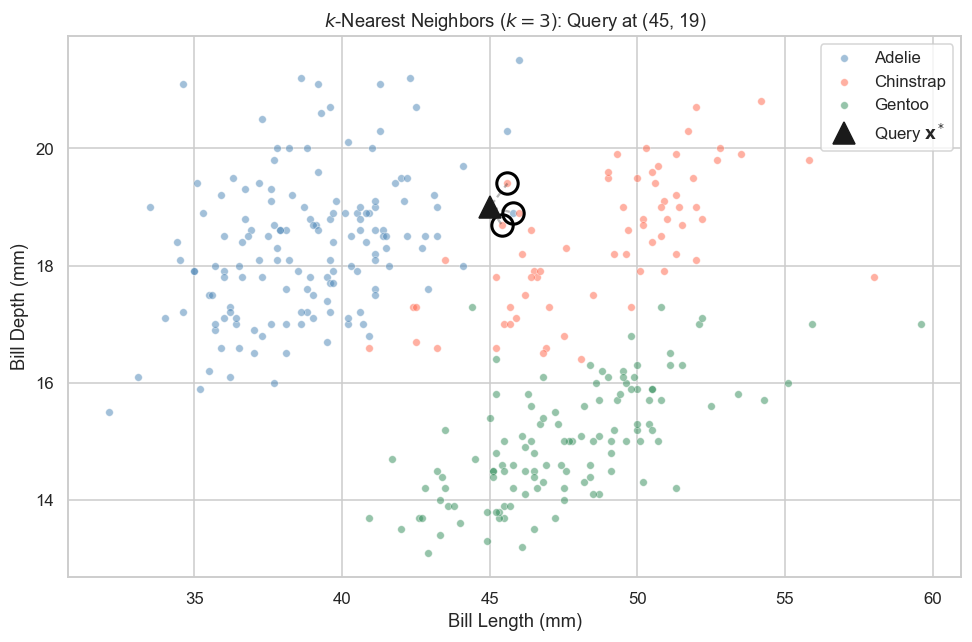

In [119]:
# Visualize kNN classification
fig, ax = plt.subplots(figsize=(9, 6))

for sp, color in species_colors.items():
    mask = y_species == sp
    ax.scatter(X_knn[mask, 0], X_knn[mask, 1], c=color, label=sp,
              alpha=0.5, s=25, edgecolors='white', linewidth=0.5)

# Highlight the query point
ax.plot(x_star[0], x_star[1], 'k^', markersize=14, zorder=5, label=r'Query $\mathbf{x}^*$')

# Highlight the k nearest neighbors
for idx in nearest_idx:
    ax.plot(X_knn[idx, 0], X_knn[idx, 1], 'o', markersize=14,
            markerfacecolor='none', markeredgecolor='black', markeredgewidth=2)

# Draw lines from query to nearest neighbors
for idx in nearest_idx:
    ax.plot([x_star[0], X_knn[idx, 0]], [x_star[1], X_knn[idx, 1]],
            'k--', alpha=0.3)

ax.set_xlabel('Bill Length (mm)')
ax.set_ylabel('Bill Depth (mm)')
ax.set_title(f'$k$-Nearest Neighbors ($k={k}$): Query at ({x_star[0]}, {x_star[1]})')
ax.legend()
plt.tight_layout()
plt.show()

### Choosing $k$: The Effect of the Number of Neighbors

$k$ is a **hyperparameter**: a user-defined setting not estimated during model fitting.

- **$k$ too small**: predictions are based on very few instances => **high variance** (sensitive to noise).
- **$k$ too large**: the model becomes **underfit**; the most common class dominates.
- In practice, $k$ is usually set between **3 and 15**.
- **Odd** values of $k$ are recommended (for binary problems) to avoid ties.

> **Example from the ZyBook**: With $k=3$, a penguin at (45, 19) is classified as Adelie.
> With $k=6$, the most common class from the 6 nearest neighbors is Chinstrap.
> The prediction **changes** depending on $k$!

In [120]:
# Show how the prediction changes for different values of k
print(f'Query point: x* = ({x_star[0]}, {x_star[1]})\n')
print(f'{"k":>3s}  {"Nearest Neighbor Classes":>40s}  {"Prediction"}')
print('-' * 65)

for k_val in range(1, 16):
    nearest = np.argsort(distances)[:k_val]
    classes = y_species[nearest]
    counts = Counter(classes)
    prediction = counts.most_common(1)[0][0]
    class_str = dict(counts)
    print(f'{k_val:3d}  {str(class_str):>40s}  {prediction}')

Query point: x* = (45, 19)

  k                  Nearest Neighbor Classes  Prediction
-----------------------------------------------------------------
  1                          {'Chinstrap': 1}  Chinstrap
  2                          {'Chinstrap': 2}  Chinstrap
  3             {'Chinstrap': 2, 'Adelie': 1}  Chinstrap
  4             {'Chinstrap': 3, 'Adelie': 1}  Chinstrap
  5             {'Chinstrap': 3, 'Adelie': 2}  Chinstrap
  6             {'Chinstrap': 4, 'Adelie': 2}  Chinstrap
  7             {'Chinstrap': 4, 'Adelie': 3}  Chinstrap
  8             {'Chinstrap': 5, 'Adelie': 3}  Chinstrap
  9             {'Chinstrap': 5, 'Adelie': 4}  Chinstrap
 10             {'Chinstrap': 6, 'Adelie': 4}  Chinstrap
 11             {'Chinstrap': 7, 'Adelie': 4}  Chinstrap
 12             {'Chinstrap': 7, 'Adelie': 5}  Chinstrap
 13  {'Chinstrap': 7, 'Adelie': 5, 'Gentoo': 1}  Chinstrap
 14  {'Chinstrap': 8, 'Adelie': 5, 'Gentoo': 1}  Chinstrap
 15  {'Chinstrap': 9, 'Adelie': 5, 'Gentoo': 1

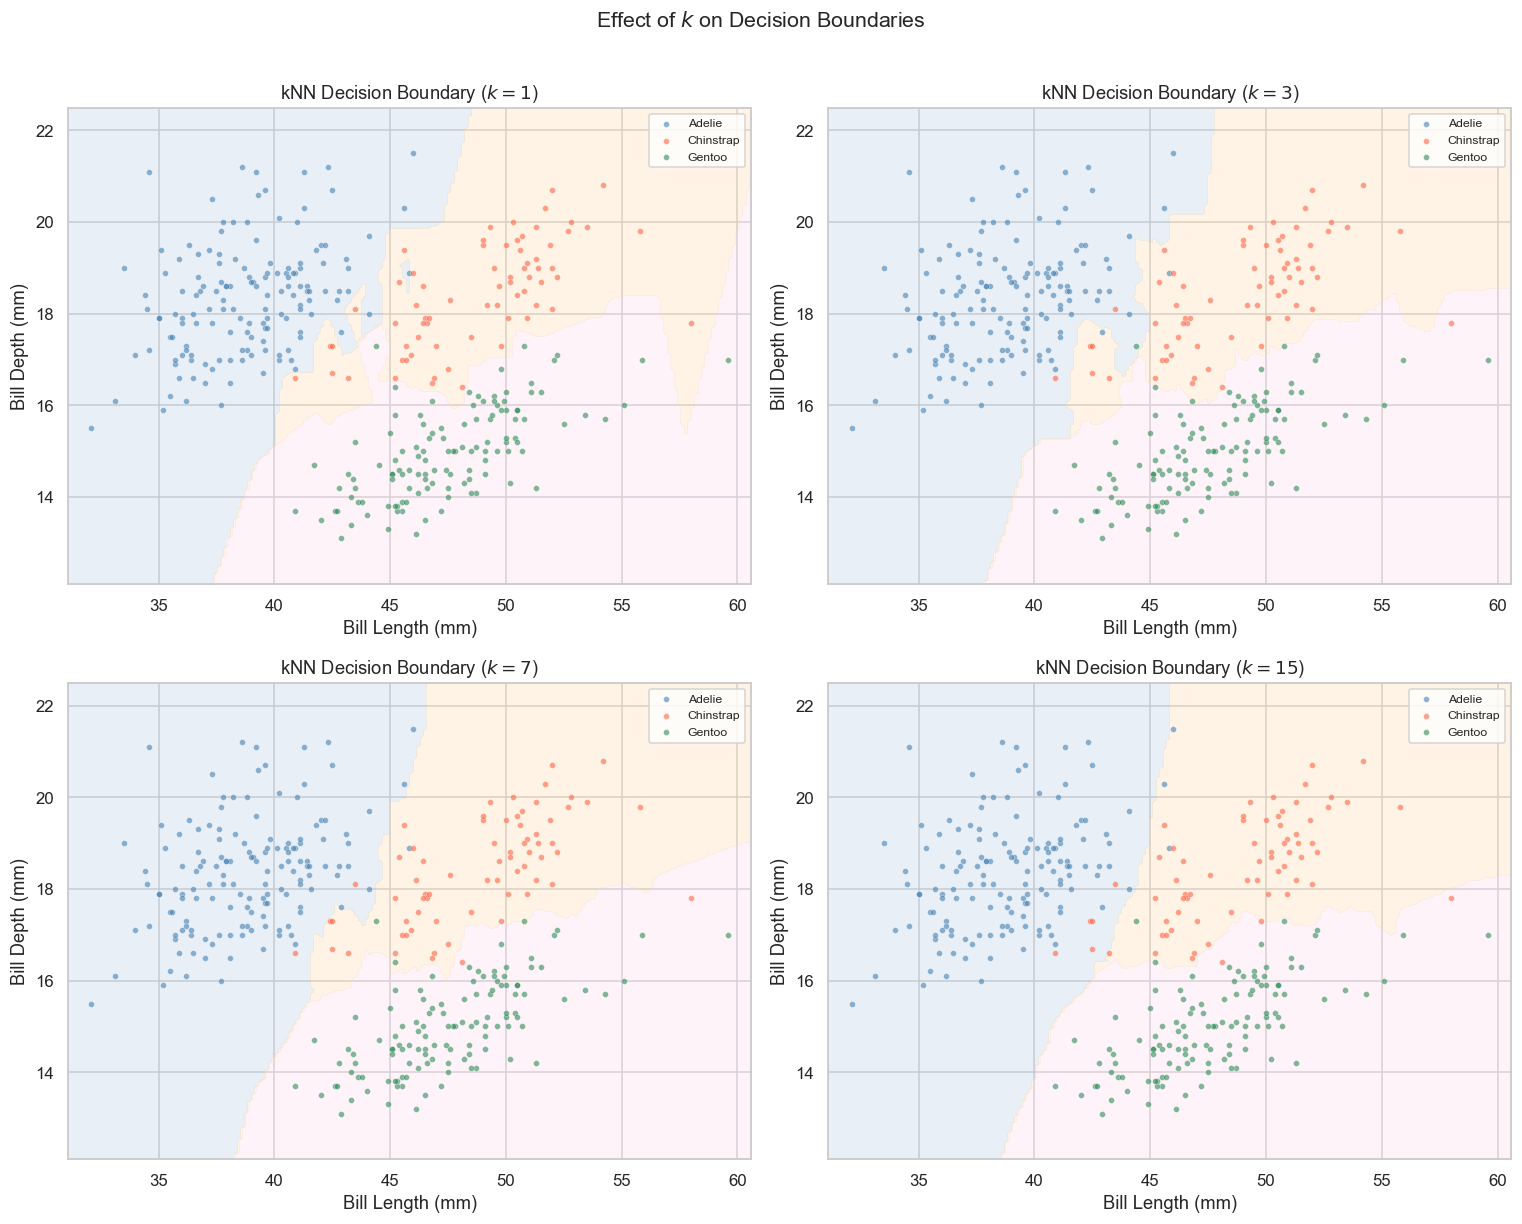

Smaller k: more complex (jagged) boundaries. Larger k: smoother boundaries.


In [121]:
# Decision boundary plots for different values of k
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
k_values = [1, 3, 7, 15]

x1_min, x1_max = X_knn[:, 0].min() - 1, X_knn[:, 0].max() + 1
x2_min, x2_max = X_knn[:, 1].min() - 1, X_knn[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                        np.linspace(x2_min, x2_max, 200))
grid_pts = np.c_[xx1.ravel(), xx2.ravel()]

# Encode species as integers for coloring
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y_species)

cmap_bg = plt.cm.Pastel1
cmap_pts = plt.cm.Set1

for ax, k_val in zip(axes.ravel(), k_values):
    knn = KNeighborsClassifier(n_neighbors=k_val)
    knn.fit(X_knn, y_enc)
    Z = knn.predict(grid_pts).reshape(xx1.shape)

    ax.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap_bg, levels=[-0.5, 0.5, 1.5, 2.5])
    for cls_idx, (sp, color) in enumerate(species_colors.items()):
        mask = y_enc == cls_idx
        ax.scatter(X_knn[mask, 0], X_knn[mask, 1], c=color, label=sp,
                  s=15, alpha=0.6, edgecolors='white', linewidth=0.3)
    ax.set_xlabel('Bill Length (mm)')
    ax.set_ylabel('Bill Depth (mm)')
    ax.set_title(f'kNN Decision Boundary ($k={k_val}$)')
    ax.legend(fontsize=8)

plt.suptitle(r'Effect of $k$ on Decision Boundaries', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Smaller k: more complex (jagged) boundaries. Larger k: smoother boundaries.')

---
### Distance Measures (Sec. 7.2)

kNN classifies based on the **closest** instances, but "closest" depends on the **distance measure**.

Consider two instances $j$ and $k$ with $p$ features:

**Euclidean Distance** (straight-line):
$$d_E(j, k) = \sqrt{\sum_{i=1}^{p}(x_{ij} - x_{ik})^2}$$

**Manhattan Distance** (city-block):
$$d_M(j, k) = \sum_{i=1}^{p} |x_{ij} - x_{ik}|$$

**Minkowski Distance** (generalized):
$$d_m(j, k) = \left(\sum_{i=1}^{p} |x_{ij} - x_{ik}|^m\right)^{1/m}$$

- Euclidean = Minkowski with $m = 2$
- Manhattan = Minkowski with $m = 1$

> **Example from ZyBook**:
> - $x^* = (45, 19)$, Instance $A = (43.2, 18.5)$
> - $d_E = \sqrt{(43.2-45)^2 + (18.5-19)^2} = 1.9$
> - $d_M = |43.2-45| + |18.5-19| = 2.3$

In [122]:
# Demonstrate different distance measures
from scipy.spatial.distance import euclidean, cityblock, minkowski

x_star = np.array([45, 19])
A = np.array([43.2, 18.5])
B = np.array([45.2, 19.8])

print('Distance calculations from x* = (45, 19):')
print(f'{"":>12s}  {"Euclidean":>10s}  {"Manhattan":>10s}  {"Minkowski(m=0.5)":>18s}')
print('-' * 56)

for name, pt in [('A (43.2, 18.5)', A), ('B (45.2, 19.8)', B)]:
    d_e = euclidean(x_star, pt)
    d_m = cityblock(x_star, pt)
    d_mk = minkowski(x_star, pt, p=0.5)
    print(f'{name:>12s}  {d_e:10.2f}  {d_m:10.2f}  {d_mk:18.2f}')

print('\nNote: Different distance measures can change which instance is "nearest".')

Distance calculations from x* = (45, 19):
               Euclidean   Manhattan    Minkowski(m=0.5)
--------------------------------------------------------
A (43.2, 18.5)        1.87        2.30                4.20
B (45.2, 19.8)        0.82        1.00                1.80

Note: Different distance measures can change which instance is "nearest".


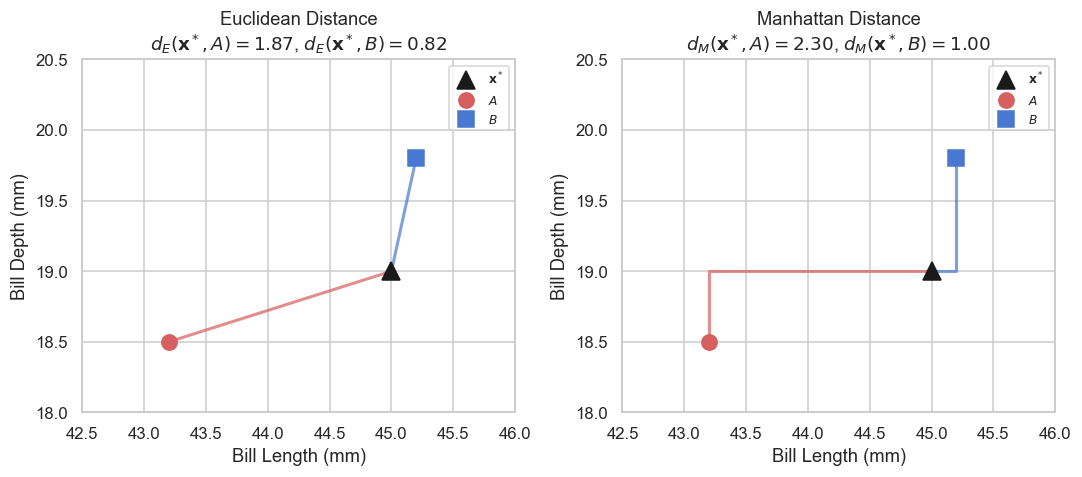

In [123]:
# Visualize the distance types
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for ax in axes:
    ax.plot(*x_star, 'k^', markersize=12, zorder=5, label=r'$\mathbf{x}^*$')
    ax.plot(*A, 'ro', markersize=10, zorder=5, label=r'$A$')
    ax.plot(*B, 'bs', markersize=10, zorder=5, label=r'$B$')
    ax.set_xlim(42.5, 46)
    ax.set_ylim(18, 20.5)
    ax.set_xlabel('Bill Length (mm)')
    ax.set_ylabel('Bill Depth (mm)')

# Panel 1 - Euclidean
axes[0].plot([x_star[0], A[0]], [x_star[1], A[1]], 'r-', linewidth=2, alpha=0.7)
axes[0].plot([x_star[0], B[0]], [x_star[1], B[1]], 'b-', linewidth=2, alpha=0.7)
axes[0].set_title(f'Euclidean Distance\n$d_E(\mathbf{{x}}^*,A)={euclidean(x_star,A):.2f}$, $d_E(\mathbf{{x}}^*,B)={euclidean(x_star,B):.2f}$')
axes[0].legend(fontsize=8)

# Panel 2 - Manhattan
axes[1].plot([x_star[0], A[0], A[0]], [x_star[1], x_star[1], A[1]], 'r-', linewidth=2, alpha=0.7)
axes[1].plot([x_star[0], B[0], B[0]], [x_star[1], x_star[1], B[1]], 'b-', linewidth=2, alpha=0.7)
axes[1].set_title(f'Manhattan Distance\n$d_M(\mathbf{{x}}^*,A)={cityblock(x_star,A):.2f}$, $d_M(\mathbf{{x}}^*,B)={cityblock(x_star,B):.2f}$')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Effect of Distance Metric on Decision Boundaries

Just as we saw that changing $k$ reshapes the decision boundary, changing the **distance metric** also changes _which_ points are "nearest" and therefore changes the predictions.

Each metric defines a different "shape" for equidistant points around a center:

| Metric | Equidistant Shape | Boundary Tendency |
|---|---|---|
| **Manhattan** ($p=1$) | Diamond | Axis-aligned (horizontal / vertical) |
| **Euclidean** ($p=2$) | Circle | Diagonal / smooth curves |
| **Minkowski** ($p=10$) | Rounded square | Approaching axis-parallel edges |
| **Chebyshev** ($p=\infty$) | Square | Axis-parallel edges |

> As $p$ increases, the equidistant contour morphs from a **diamond** -> **circle** -> **square**, which reshapes the decision boundary.

To see this clearly, we use a small **XOR-like** synthetic dataset and $k=1$ (so boundaries are pure Voronoi cells reflecting the metric's geometry).

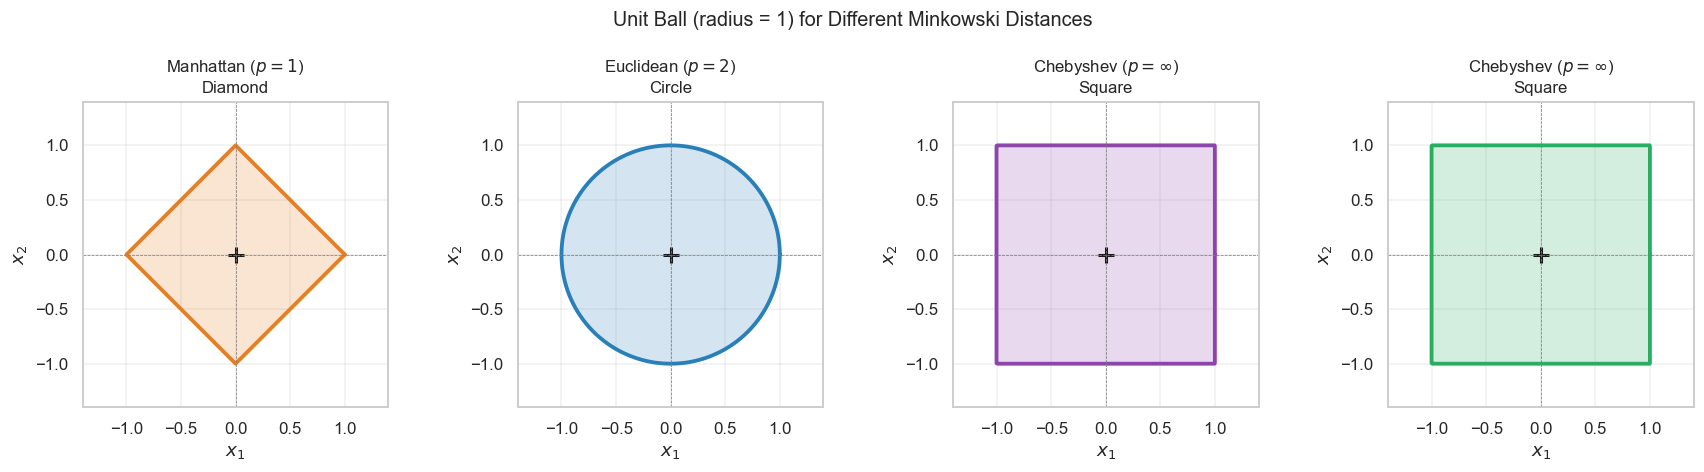

All points ON the boundary are at distance = 1 from the center.
Diamond -> Circle -> Square as p goes from 1 -> 2 -> inf


In [124]:
p_mk = None

# Each entry: (display_label, p_value, shape_description, color)
# Use np.inf for Chebyshev (p = inf)
ball_configs = [
    ('Manhattan ($p=1$)',               1,      'Diamond',          '#e67e22'),
    ('Euclidean ($p=2$)',               2,      'Circle',           '#2980b9'),
    (f'Minkowski ($p={p_mk}$)' if p_mk is not None else 'Chebyshev ($p=\\infty$)',
     p_mk if p_mk is not None else np.inf, 'Rounded square' if (p_mk is not None and p_mk > 2) else 'Square', '#8e44ad'),
    ('Chebyshev ($p=\\infty$)',         np.inf, 'Square',           '#27ae60'),
]
# ---------------------------------------------------------

theta = np.linspace(0, 2 * np.pi, 1000)
fig, axes = plt.subplots(1, len(ball_configs), figsize=(4 * len(ball_configs), 4))
if len(ball_configs) == 1:
    axes = [axes]

for ax, (label, p_ball, shape_name, clr) in zip(axes, ball_configs):
    if np.isinf(p_ball):
        # Chebyshev: max(|x|,|y|) = 1 -> square
        x_ball = np.clip(np.cos(theta) / np.maximum(np.abs(np.cos(theta)), np.abs(np.sin(theta))), -1, 1)
        y_ball = np.clip(np.sin(theta) / np.maximum(np.abs(np.cos(theta)), np.abs(np.sin(theta))), -1, 1)
    else:
        x_ball = np.sign(np.cos(theta)) * np.abs(np.cos(theta)) ** (2.0 / p_ball)
        y_ball = np.sign(np.sin(theta)) * np.abs(np.sin(theta)) ** (2.0 / p_ball)

    ax.fill(x_ball, y_ball, alpha=0.20, color=clr)
    ax.plot(x_ball, y_ball, color=clr, linewidth=2.5)
    ax.plot(0, 0, 'k+', markersize=10, markeredgewidth=2)
    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-1.4, 1.4)
    ax.set_aspect('equal')
    ax.set_title(f'{label}\n{shape_name}', fontsize=11)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.grid(True, alpha=0.3)

plt.suptitle('Unit Ball (radius = 1) for Different Minkowski Distances',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('All points ON the boundary are at distance = 1 from the center.')
print('Diamond -> Circle -> Square as p goes from 1 -> 2 -> inf')

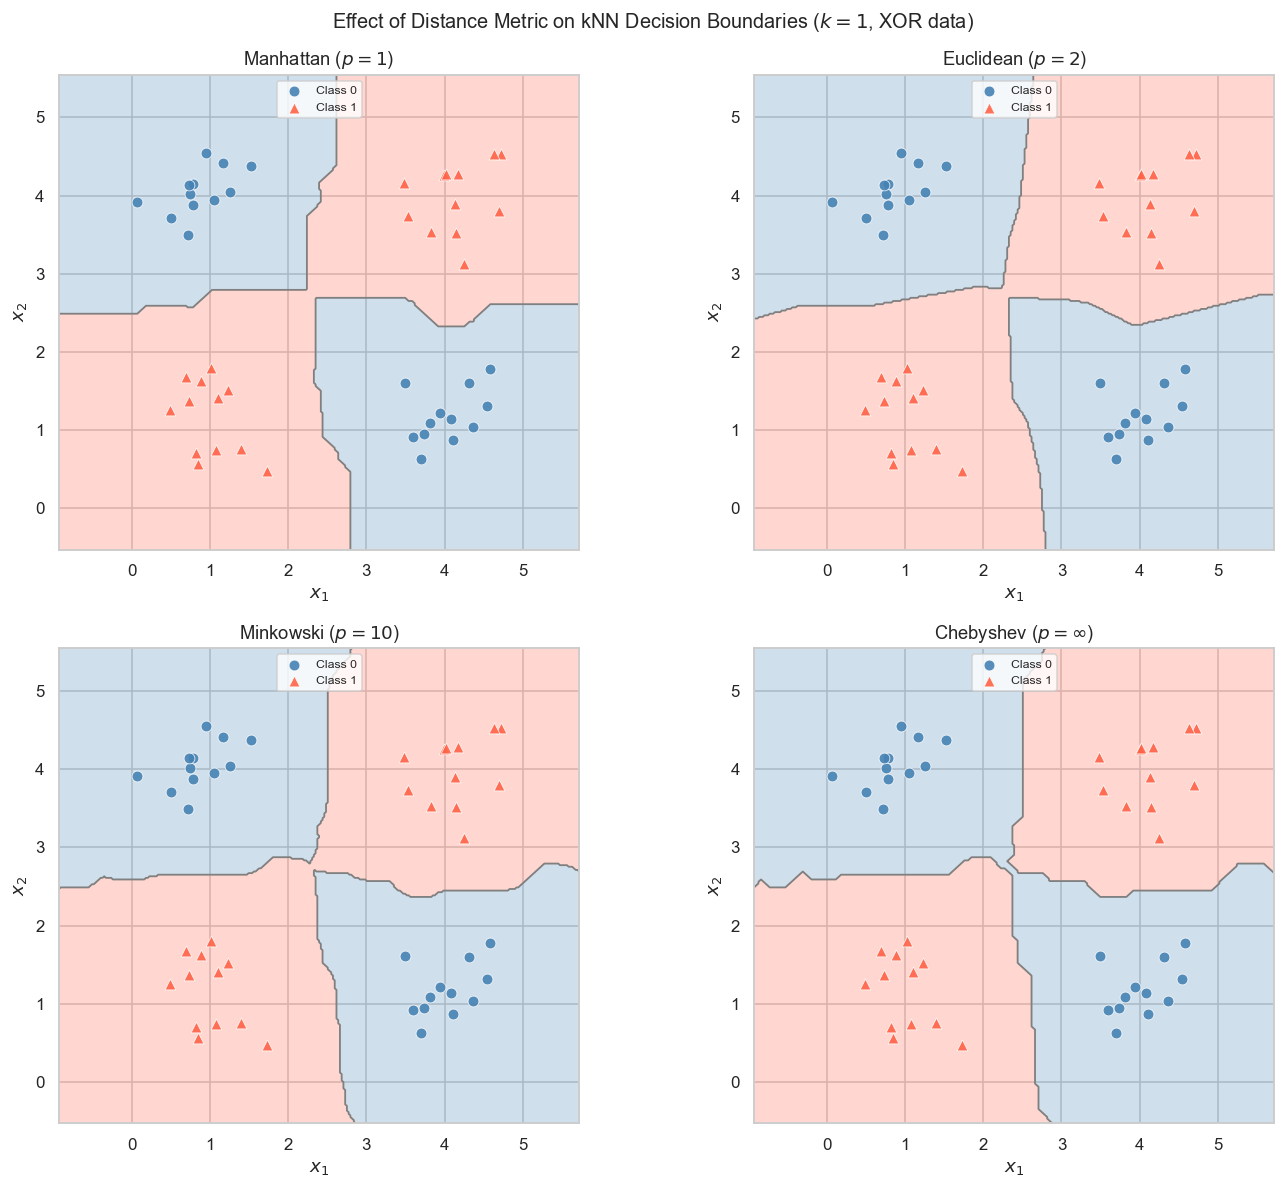

Manhattan: diamond-shaped Voronoi cells, axis-aligned boundaries
Euclidean: circular Voronoi cells, smooth diagonal boundaries
Chebyshev: square Voronoi cells, axis-parallel block boundaries

Notice how the grey boundary lines change shape across the four panels.


In [125]:
# Synthetic XOR-like dataset - metric differences are dramatic here
rng_demo = np.random.default_rng(0)

# Class 0 (blue): top-left and bottom-right clusters
c0 = np.vstack([rng_demo.normal(loc=[1, 4], scale=0.4, size=(12, 2)),
                rng_demo.normal(loc=[4, 1], scale=0.4, size=(12, 2))])
# Class 1 (red): top-right and bottom-left clusters
c1 = np.vstack([rng_demo.normal(loc=[4, 4], scale=0.4, size=(12, 2)),
                rng_demo.normal(loc=[1, 1], scale=0.4, size=(12, 2))])

X_demo = np.vstack([c0, c1])
y_demo = np.array([0]*len(c0) + [1]*len(c1))

distance_configs = [
    ('Manhattan ($p=1$)',        'minkowski', 1),
    ('Euclidean ($p=2$)',        'minkowski', 2),
    ('Minkowski ($p=10$)',       'minkowski', 10),
    ('Chebyshev ($p=\\infty$)',  'chebyshev', None),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

x1_min, x1_max = X_demo[:, 0].min() - 1, X_demo[:, 0].max() + 1
x2_min, x2_max = X_demo[:, 1].min() - 1, X_demo[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                        np.linspace(x2_min, x2_max, 300))
grid_pts = np.c_[xx1.ravel(), xx2.ravel()]

demo_colors = {0: 'steelblue', 1: 'tomato'}
demo_markers = {0: 'o', 1: '^'}
demo_labels = {0: 'Class 0', 1: 'Class 1'}

for ax, (label, metric, p_val) in zip(axes.ravel(), distance_configs):
    if metric == 'chebyshev':
        knn = KNeighborsClassifier(n_neighbors=1, metric='chebyshev')
    else:
        knn = KNeighborsClassifier(n_neighbors=1, metric=metric, p=p_val)
    knn.fit(X_demo, y_demo)
    Z = knn.predict(grid_pts).reshape(xx1.shape)

    ax.contourf(xx1, xx2, Z, alpha=0.25,
                colors=['steelblue', 'tomato'], levels=[-0.5, 0.5, 1.5])
    ax.contour(xx1, xx2, Z, colors='grey', linewidths=1.2, levels=[0.5])
    for cls in [0, 1]:
        mask = y_demo == cls
        ax.scatter(X_demo[mask, 0], X_demo[mask, 1],
                   c=demo_colors[cls], marker=demo_markers[cls],
                   s=50, alpha=0.9, edgecolors='white', linewidth=0.5,
                   label=demo_labels[cls])
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(label, fontsize=12)
    ax.legend(fontsize=8, loc='upper center')
    ax.set_aspect('equal')

plt.suptitle('Effect of Distance Metric on kNN Decision Boundaries ($k=1$, XOR data)',
             fontsize=13)
plt.tight_layout()
plt.show()

print('Manhattan: diamond-shaped Voronoi cells, axis-aligned boundaries')
print('Euclidean: circular Voronoi cells, smooth diagonal boundaries')
print('Chebyshev: square Voronoi cells, axis-parallel block boundaries')
print('\nNotice how the grey boundary lines change shape across the four panels.')

### Effect of `weights` on Decision Boundaries

`KNeighborsClassifier` supports two weighting schemes:

| `weights=` | How neighbors vote | Effect |
|---|---|---|
| `"uniform"` (default) | Every neighbor counts equally | Boundary determined by simple majority |
| `"distance"` | Closer neighbors have more influence ($w_i = 1 / d_i$) | Boundary shifts toward farther neighbors: **smoother**, more "local" |

> With **uniform** weighting and $k=15$, a distant neighbor has the same vote as the nearest one.
> With **distance** weighting, the nearest neighbor dominates; the boundary becomes more responsive to nearby points.

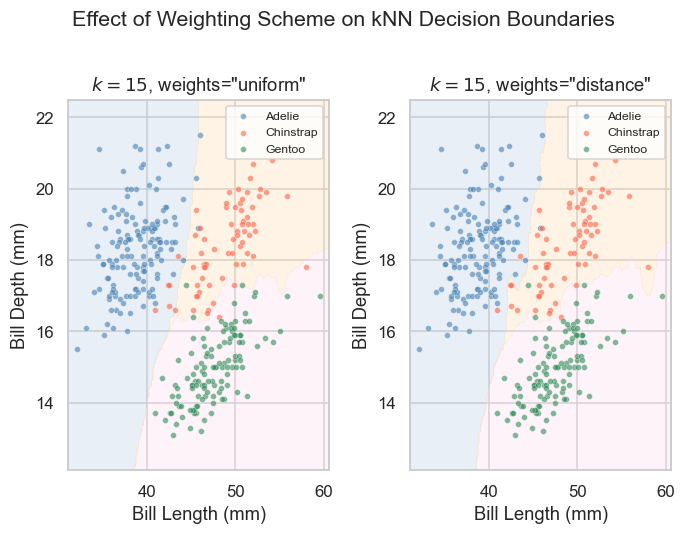

Top row (k=5):  uniform vs distance; small k, differences are subtle.
Bottom row (k=15): uniform vs distance; large k, distance weighting
  keeps boundaries more complex (close to the data) while uniform smooths them out.


In [126]:
# Effect of weights on decision boundaries (penguin data, 2 features)
fig, axes = plt.subplots(1, 2)

weight_k_configs = [
    ('uniform', 15),
    ('distance', 15),
]

x1_min, x1_max = X_knn[:, 0].min() - 1, X_knn[:, 0].max() + 1
x2_min, x2_max = X_knn[:, 1].min() - 1, X_knn[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                        np.linspace(x2_min, x2_max, 200))
grid_pts = np.c_[xx1.ravel(), xx2.ravel()]

for ax, (w, k_val) in zip(axes.ravel(), weight_k_configs):
    knn = KNeighborsClassifier(n_neighbors=k_val, weights=w)
    knn.fit(X_knn, y_enc)
    Z = knn.predict(grid_pts).reshape(xx1.shape)

    ax.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap_bg, levels=[-0.5, 0.5, 1.5, 2.5])
    for cls_idx, (sp, color) in enumerate(species_colors.items()):
        mask = y_enc == cls_idx
        ax.scatter(X_knn[mask, 0], X_knn[mask, 1], c=color, label=sp,
                  s=15, alpha=0.6, edgecolors='white', linewidth=0.3)
    ax.set_xlabel('Bill Length (mm)')
    ax.set_ylabel('Bill Depth (mm)')
    ax.set_title(f'$k={k_val}$, weights="{w}"', fontsize=12)
    ax.legend(fontsize=8)

plt.suptitle('Effect of Weighting Scheme on kNN Decision Boundaries', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Top row (k=5):  uniform vs distance; small k, differences are subtle.')
print('Bottom row (k=15): uniform vs distance; large k, distance weighting')
print('  keeps boundaries more complex (close to the data) while uniform smooths them out.')

---
### k-Nearest Neighbors in scikit-learn

Three-step workflow:
1. **Initialize**: `KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)`
2. **Fit**: `model.fit(X, y)`
3. **Predict**: `model.predict(X_new)`

`KNeighborsClassifier()` key parameters:

| Parameter | Default | Description |
|---|---|---|
| `n_neighbors` | `5` | Number of neighbors $k$ |
| `metric` | `"minkowski"` | Distance measure |
| `p` | `2` | Minkowski power: `p=1` = Manhattan, `p=2` = Euclidean |
| `weights` | `"uniform"` | `"uniform"` = equal weight; `"distance"` = inverse distance weighting |

In [127]:
# kNN with scikit-learn (multiclass: 3 penguin species)
X_two_knn = penguins[['bill_length_mm', 'bill_depth_mm']].values
y_species_arr = penguins['species'].values

X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
    X_two_knn, y_species_arr, test_size=0.2, random_state=42, stratify=y_species_arr)

# Initialize and fit
knn_model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn_model.fit(X_train_k, y_train_k)

# Predict
y_pred_k = knn_model.predict(X_test_k)

print(f'kNN (k=5, Euclidean) - 2 features')
print(f'  Train accuracy: {knn_model.score(X_train_k, y_train_k):.3f}')
print(f'  Test accuracy:  {knn_model.score(X_test_k, y_test_k):.3f}')
print()
print('Classification Report:')
print(metrics.classification_report(y_test_k, y_pred_k))

kNN (k=5, Euclidean) - 2 features
  Train accuracy: 0.974
  Test accuracy:  0.970

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      0.93      0.93        14
      Gentoo       0.96      1.00      0.98        24

    accuracy                           0.97        67
   macro avg       0.96      0.96      0.96        67
weighted avg       0.97      0.97      0.97        67



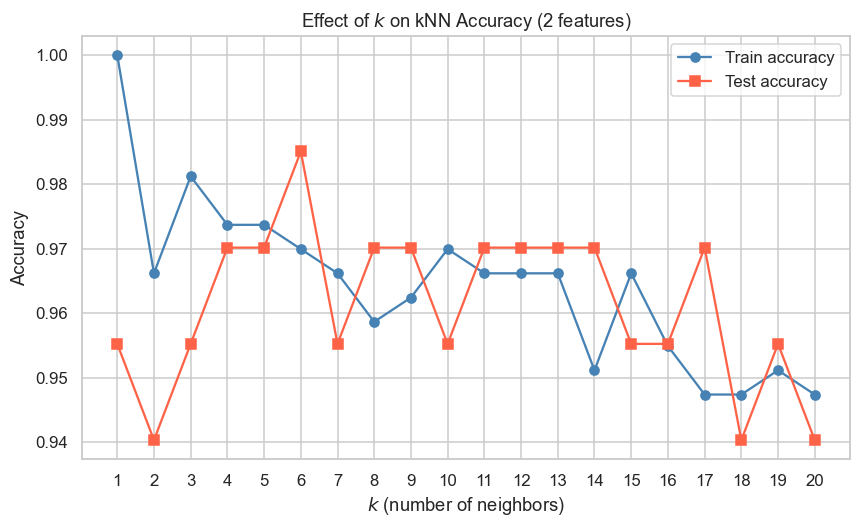

Best test accuracy at k=6: 0.985


In [128]:
# Explore different k values
k_range = range(1, 21)
train_scores = []
test_scores = []

for k_val in k_range:
    knn = KNeighborsClassifier(n_neighbors=k_val)
    knn.fit(X_train_k, y_train_k)
    train_scores.append(knn.score(X_train_k, y_train_k))
    test_scores.append(knn.score(X_test_k, y_test_k))

plt.figure(figsize=(9, 5))
plt.plot(k_range, train_scores, 'o-', label='Train accuracy', color='steelblue')
plt.plot(k_range, test_scores, 's-', label='Test accuracy', color='tomato')
plt.xlabel(r'$k$ (number of neighbors)')
plt.ylabel('Accuracy')
plt.title(r'Effect of $k$ on kNN Accuracy (2 features)')
plt.xticks(list(k_range))
plt.legend()
plt.show()

best_k = list(k_range)[np.argmax(test_scores)]
print(f'Best test accuracy at k={best_k}: {max(test_scores):.3f}')

---
### Standardization: Why It Matters for kNN (Sec. 7.2)

Distance-based algorithms like kNN are **sensitive to the scale** of features.

| Feature | Mean | SD |
|---|---|---|
| Bill length (mm) | 44 | 5 |
| Bill depth (mm) | 17 | 2 |
| Flipper length (mm) | 201 | 14 |
| Body mass (g) | 4207 | 805 |

Body mass ranges in the thousands while bill depth ranges in the teens.
Without standardization, **body mass dominates** the distance calculation.

**Standardization** rescales each feature to have mean 0 and standard deviation 1:
$$z = \frac{x - \bar{x}}{s}$$

These standardized values are also called **z-scores**.

In [129]:
# Compare kNN with and without standardization (all 4 numeric features)
feature_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X_all = penguins[feature_cols].values
y_all = penguins['species'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

# ----- WITHOUT standardization -----
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_tr, y_tr)
acc_raw = knn_raw.score(X_te, y_te)

# ----- WITH standardization -----
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)     # transform only - don't re-fit!

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_tr_scaled, y_tr)
acc_scaled = knn_scaled.score(X_te_scaled, y_te)

print(f'kNN (k=5) with 4 features:')
print(f'  Without standardization -> accuracy = {acc_raw:.3f}')
print(f'  With standardization    -> accuracy = {acc_scaled:.3f}')
print(f'\n  Improvement: {acc_scaled - acc_raw:+.3f}')

kNN (k=5) with 4 features:
  Without standardization -> accuracy = 0.731
  With standardization    -> accuracy = 1.000

  Improvement: +0.269


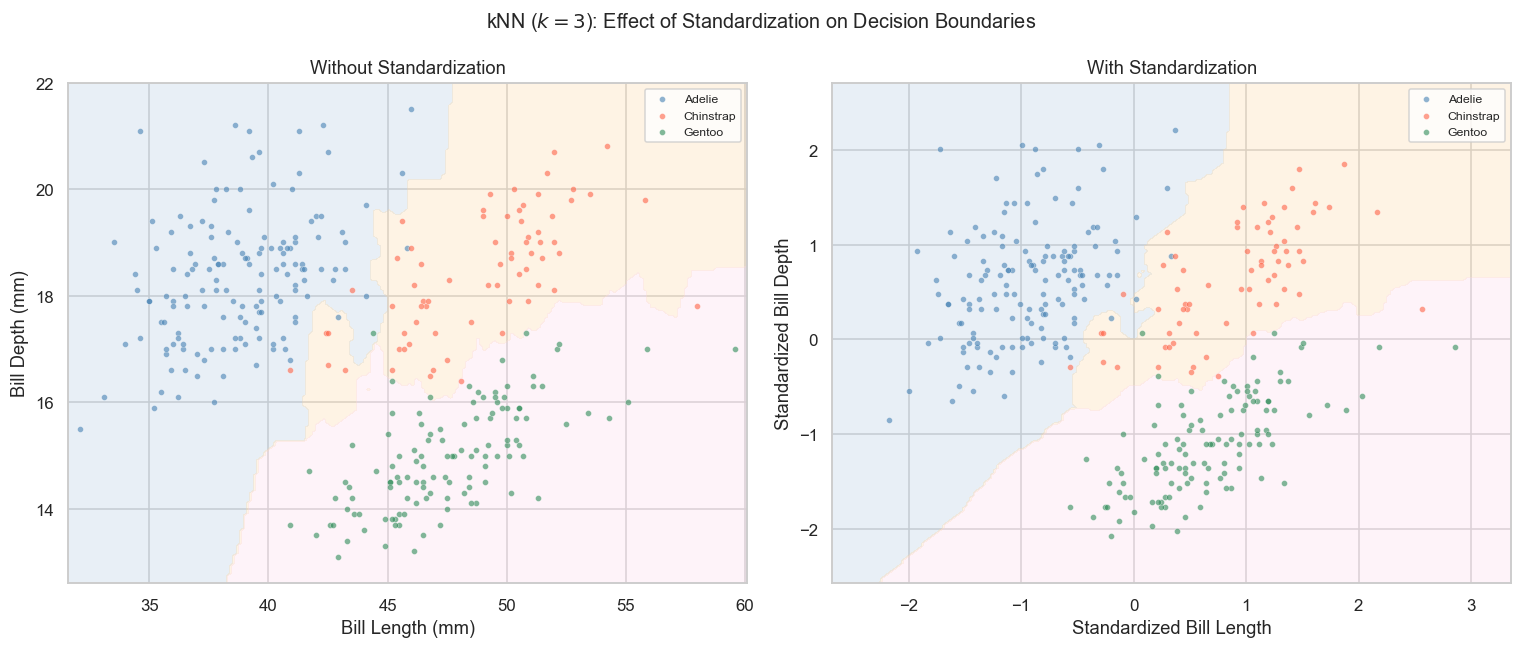

In [130]:
# Visualize the effect: decision boundaries with vs without standardization (2 features)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

X_2f = penguins[['bill_length_mm', 'bill_depth_mm']].values
y_sp = penguins['species'].values

# Encode species
y_enc_2 = le.transform(y_sp)

for ax_idx, (title, do_scale) in enumerate([('Without Standardization', False),
                                              ('With Standardization', True)]):
    ax = axes[ax_idx]

    if do_scale:
        sc = StandardScaler()
        X_plot = sc.fit_transform(X_2f)
    else:
        X_plot = X_2f.copy()

    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_plot, y_enc_2)

    x1_min, x1_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
    x2_min, x2_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                            np.linspace(x2_min, x2_max, 200))
    Z = knn.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)

    ax.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap_bg, levels=[-0.5, 0.5, 1.5, 2.5])
    for cls_idx, (sp, color) in enumerate(species_colors.items()):
        mask = y_enc_2 == cls_idx
        ax.scatter(X_plot[mask, 0], X_plot[mask, 1], c=color, label=sp,
                  s=15, alpha=0.6, edgecolors='white', linewidth=0.3)

    if do_scale:
        ax.set_xlabel('Standardized Bill Length')
        ax.set_ylabel('Standardized Bill Depth')
    else:
        ax.set_xlabel('Bill Length (mm)')
        ax.set_ylabel('Bill Depth (mm)')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle(r'kNN ($k=3$): Effect of Standardization on Decision Boundaries', fontsize=13)
plt.tight_layout()
plt.show()

### Advantages and Disadvantages of kNN

| Advantages | Disadvantages |
|---|---|
| Simple and intuitive | Sensitive to feature scale (needs standardization) |
| No training phase (lazy learner) | Slow prediction for large datasets |
| Naturally handles multi-class | Cannot describe relationships between features |
| Non-parametric: no assumptions about data distribution | Performance degrades in high dimensions (curse of dimensionality) |

---
## Part 3 - Comparing Logistic Regression vs kNN

| Property | Logistic Regression | k-Nearest Neighbors |
|---|---|---|
| Type | Model-based | Instance-based |
| Classes | Binary (one-vs-rest for multiclass) | Any number of classes |
| Decision boundary | Linear | Nonlinear |
| Interpretability | Weights describe feature importance | No interpretable model |
| Feature scaling | Generally not required | **Required** |
| Hyperparameters | penalty, max_iter | k, metric, p |
| Outputs probabilities? | Yes (sigmoid function) | Yes (proportion of neighbors) |

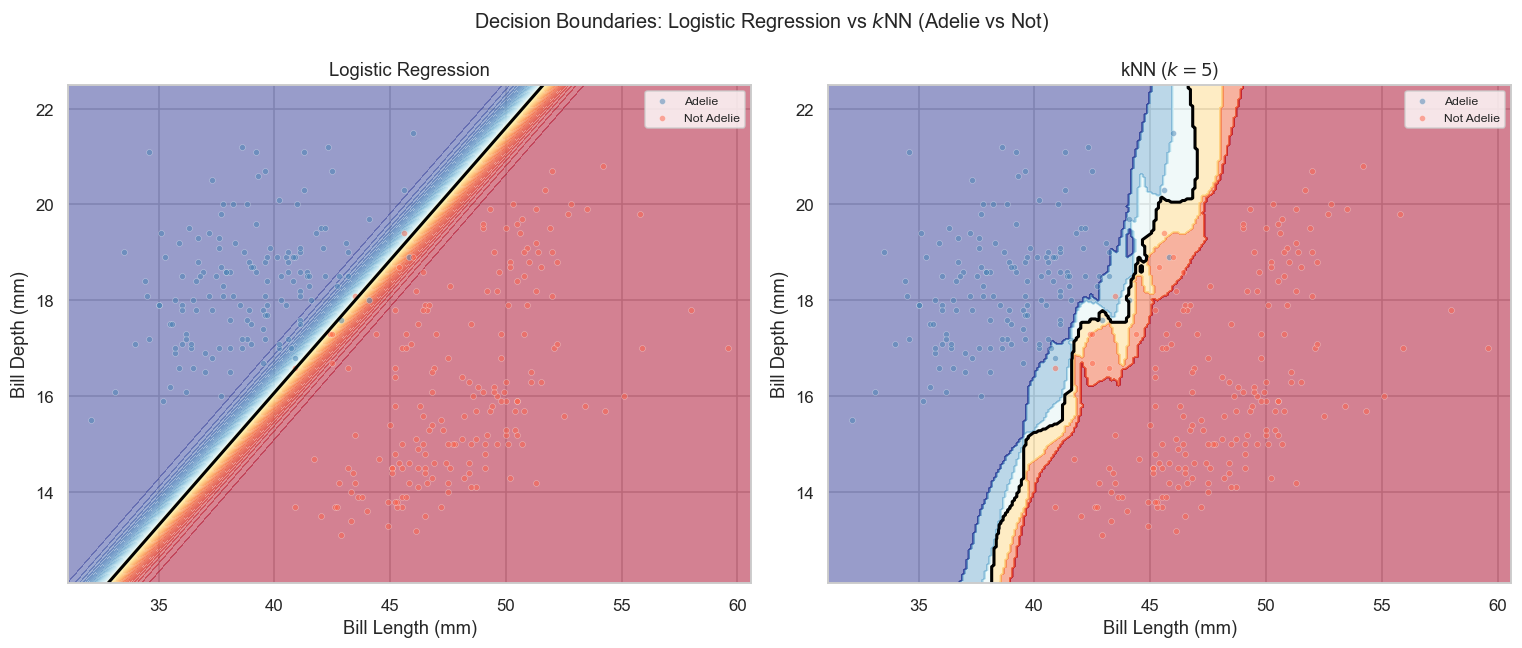

Logistic regression: straight-line boundary.
kNN: flexible, curved boundary that adapts to local structure.


In [131]:
# Side-by-side comparison: Logistic Regression vs kNN decision boundaries
# We use the binary classification problem: Adelie vs not Adelie
X_comp = penguins[['bill_length_mm', 'bill_depth_mm']].values
y_comp = penguins['is_adelie'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x1_min, x1_max = X_comp[:, 0].min() - 1, X_comp[:, 0].max() + 1
x2_min, x2_max = X_comp[:, 1].min() - 1, X_comp[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                        np.linspace(x2_min, x2_max, 300))
grid_pts = np.c_[xx1.ravel(), xx2.ravel()]

models = [
    ('Logistic Regression', LogisticRegression(penalty=None, max_iter=1000)),
    (r'kNN ($k=5$)', KNeighborsClassifier(n_neighbors=5)),
]

for ax, (name, model) in zip(axes, models):
    model.fit(X_comp, y_comp)
    Z = model.predict_proba(grid_pts)[:, 1].reshape(xx1.shape)

    contour = ax.contourf(xx1, xx2, Z, levels=50, cmap='RdYlBu', alpha=0.5)
    ax.contour(xx1, xx2, Z, levels=[0.5], colors='black', linewidths=2)

    for label, color in [('Adelie', 'steelblue'), ('Not Adelie', 'tomato')]:
        mask = y_comp == (1 if label == 'Adelie' else 0)
        ax.scatter(X_comp[mask, 0], X_comp[mask, 1], c=color, label=label,
                  s=15, alpha=0.5, edgecolors='white', linewidth=0.3)

    ax.set_xlabel('Bill Length (mm)')
    ax.set_ylabel('Bill Depth (mm)')
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.suptitle(r'Decision Boundaries: Logistic Regression vs $k$NN (Adelie vs Not)', fontsize=13)
plt.tight_layout()
plt.show()

print('Logistic regression: straight-line boundary.')
print('kNN: flexible, curved boundary that adapts to local structure.')

In [132]:
# Full comparison on all 4 features with proper train/test split
feature_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X_all = penguins[feature_cols].values
y_all = penguins['species'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

# Standardize for kNN
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

results = []

# Logistic Regression (multiclass: one-vs-rest)
lr = LogisticRegression(penalty='l2', max_iter=1000)
lr.fit(X_tr, y_tr)
results.append(('Logistic Regression (L2)', lr.score(X_te, y_te)))

# kNN variants
for k_val in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k_val)
    knn.fit(X_tr_s, y_tr)
    results.append((f'kNN (k={k_val}, standardized)', knn.score(X_te_s, y_te)))

# kNN without standardization
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_tr, y_tr)
results.append(('kNN (k=5, raw features)', knn_raw.score(X_te, y_te)))

print(f'{"Model":>35s}  {"Test Accuracy":>13s}')
print('-' * 52)
for name, acc in results:
    print(f'{name:>35s}  {acc:13.3f}')

                              Model  Test Accuracy
----------------------------------------------------
           Logistic Regression (L2)          0.985
            kNN (k=3, standardized)          1.000
            kNN (k=5, standardized)          1.000
            kNN (k=7, standardized)          1.000
            kNN (k=5, raw features)          0.731


---
## Summary

### Section 7.1 - Logistic Regression
- Logistic regression is a **model-based binary classification** algorithm.
- It models the **log-odds** as a linear function: $\ln(p/(1-p)) = w_0 + w_1 x$.
- The sigmoid function converts the log-odds to a probability $\hat{p} \in [0, 1]$.
- A **threshold** $T$ (typically 0.5) converts probabilities to class labels.
- Weights are **interpretable**: $w_j > 0$ means the feature increases P(class 1); $w_j < 0$ means it decreases.
- In scikit-learn: `LogisticRegression(penalty='l2', max_iter=100)`.

### Section 7.2 - k-Nearest Neighbors
- kNN is an **instance-based** classification algorithm; no explicit model is learned.
- Classify by finding the $k$ nearest neighbors and taking a **majority vote**.
- Key hyperparameters: $k$ (number of neighbors) and **distance measure** (Euclidean, Manhattan, Minkowski).
- Small $k$ => complex (high variance); large $k$ => simple (potential underfit).
- **Standardization is critical** for distance-based methods.
- In scikit-learn: `KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)`.

---

<p style="text-align: center; color: #999; font-size: 0.85em; font-style: italic; margin-top: 2em;">
SahamiS@miamioh.edu · Miami University · CSE 432/532
</p>